# FPL Analysis â€” Exploratory Data Analysis

**Database:** `db/fpl.db` â€” 242,316 GW rows across 10 seasons (2016-17 to 2025-26)

This notebook covers six analysis areas:

1. [Target Variable Analysis](#31-target-variable-analysis) â€” points distributions, blanks/hauls, pts/90
2. [Temporal Analysis](#32-temporal-analysis) â€” seasonal drift, era comparison, COVID season
3. [Position Analysis](#33-position-analysis) â€” stat profiles, MID heterogeneity, GK drivers
4. [Team & Fixture Analysis](#34-team--fixture-analysis) â€” CS rates, home/away, top-6 effect
5. [Player & Price Analysis](#35-player--price-analysis) â€” price vs points, career length, minutes
6. [Correlation & Feature Relevance](#36-correlation--feature-relevance) â€” feature correlations, lag-1, missing data

All charts are exported to `outputs/eda/`. Key findings from `logs/data_biases.md` are referenced throughout.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from scipy import stats

DB_PATH = Path('../db/fpl.db')
OUT_DIR = Path('../outputs/eda')
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql_query(sql, con, params=params)

POS_ORDER = ['GK', 'DEF', 'MID', 'FWD']
POS_COLORS = {'GK': '#1f77b4', 'DEF': '#2ca02c', 'MID': '#ff7f0e', 'FWD': '#d62728'}

print('Setup complete. DB:', DB_PATH.resolve())
print('Rows in fact_gw_player:', query('SELECT COUNT(*) AS n FROM fact_gw_player').iloc[0, 0])

Setup complete. DB: C:\Users\USER\Documents\fpl_analysis\db\fpl.db
Rows in fact_gw_player: 242316


---
## 3.1 Target Variable Analysis

The prediction target is `total_points` at the GW level. Before building features, we need to understand the shape of this distribution â€” including how it varies by position, how often players blank or haul, and what a 'per-90' normalisation reveals.

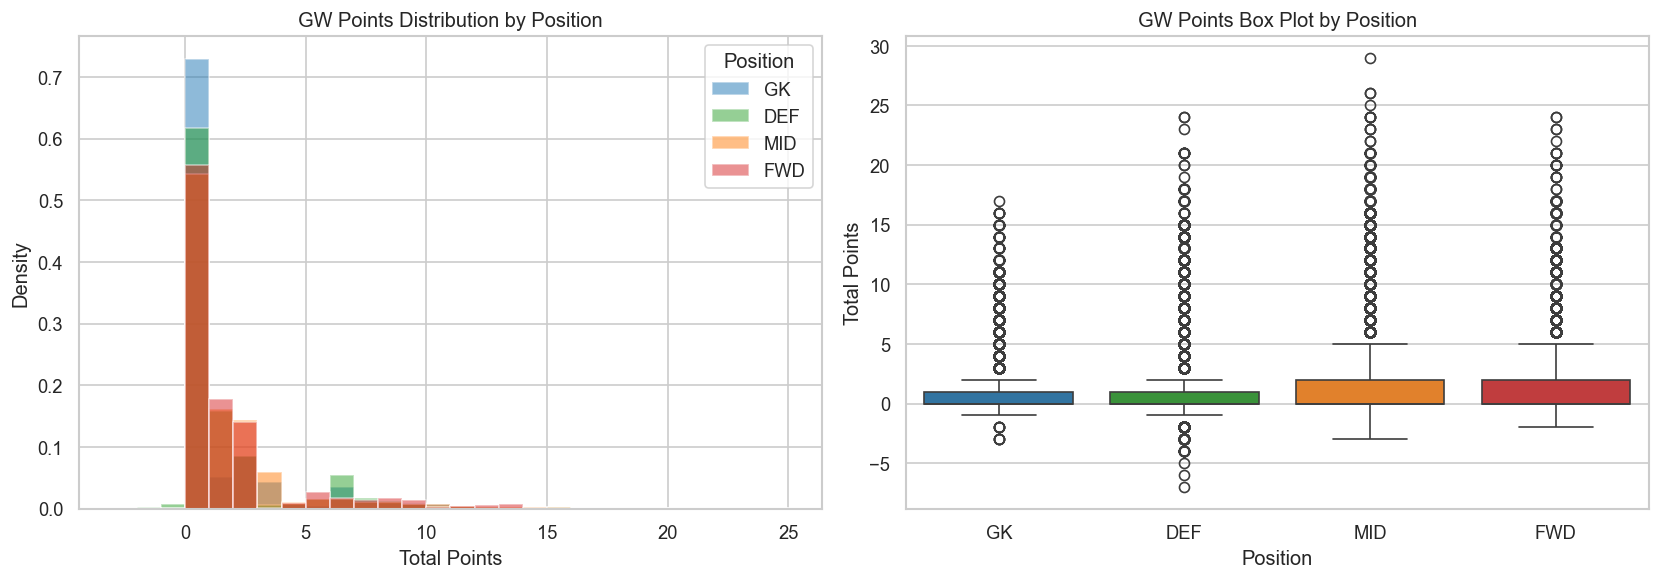

                   count  mean   std  min  25%  50%  75%   max
position_label                                                
GK               26332.0  0.99  2.18 -3.0  0.0  0.0  1.0  17.0
DEF              81540.0  1.20  2.41 -7.0  0.0  0.0  1.0  24.0
MID             102544.0  1.33  2.43 -3.0  0.0  0.0  2.0  29.0
FWD              31477.0  1.40  2.68 -2.0  0.0  0.0  2.0  24.0


In [2]:
# 3.1a â€” GW points distribution: histogram + box plot by position
df_pts = query('''
    SELECT position_label, total_points
    FROM fact_gw_player
    WHERE position_label IS NOT NULL
      AND mng_win IS NULL
''')

df_pts['position_label'] = pd.Categorical(df_pts['position_label'], categories=POS_ORDER, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for pos in POS_ORDER:
    grp = df_pts[df_pts['position_label'] == pos]
    axes[0].hist(grp['total_points'], bins=range(-3, 26), alpha=0.5,
                 label=pos, density=True, color=POS_COLORS[pos])
axes[0].set_title('GW Points Distribution by Position')
axes[0].set_xlabel('Total Points')
axes[0].set_ylabel('Density')
axes[0].legend(title='Position')

sns.boxplot(data=df_pts, x='position_label', y='total_points',
            order=POS_ORDER, hue='position_label', palette=POS_COLORS,
            legend=False, ax=axes[1])
axes[1].set_title('GW Points Box Plot by Position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Total Points')

plt.tight_layout()
plt.savefig(OUT_DIR / 'points_distribution.png')
plt.show()

print(df_pts.groupby('position_label', observed=True)['total_points'].describe().round(2))

**Interpretation:** All positions are right-skewed with a large spike at low scores. GKs and DEFs have heavier right tails on clean-sheet gameweeks; FWDs and MIDs spike on goal-scoring gameweeks. The median is 2 points across all positions.

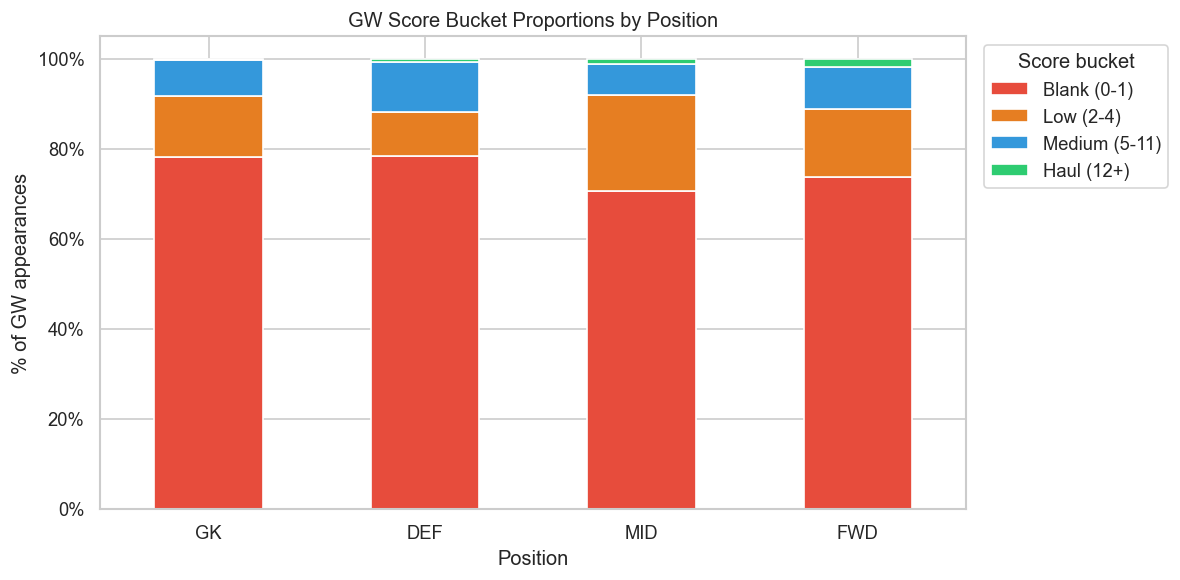

bucket          Blank (0-1)  Low (2-4)  Medium (5-11)  Haul (12+)
position_label                                                   
GK                     78.2       13.5            8.0         0.2
DEF                    78.4        9.9           11.0         0.7
MID                    70.6       21.4            6.9         1.1
FWD                    73.7       15.1            9.4         1.8


In [3]:
# 3.1b â€” Score bucket proportions: blank (0-1), low (2-4), medium (5-11), haul (12+)
df_buckets = query('''
    SELECT position_label,
           CASE
               WHEN total_points <= 1  THEN 'Blank (0-1)'
               WHEN total_points <= 4  THEN 'Low (2-4)'
               WHEN total_points <= 11 THEN 'Medium (5-11)'
               ELSE 'Haul (12+)'
           END AS bucket
    FROM fact_gw_player
    WHERE position_label IN ('GK', 'DEF', 'MID', 'FWD')
      AND mng_win IS NULL
''')

BUCKET_ORDER = ['Blank (0-1)', 'Low (2-4)', 'Medium (5-11)', 'Haul (12+)']
df_buckets['position_label'] = pd.Categorical(df_buckets['position_label'], categories=POS_ORDER, ordered=True)
df_buckets['bucket'] = pd.Categorical(df_buckets['bucket'], categories=BUCKET_ORDER, ordered=True)

counts = df_buckets.groupby(['position_label', 'bucket'], observed=True).size().reset_index(name='n')
counts['pct'] = counts.groupby('position_label', observed=True)['n'].transform(lambda x: x / x.sum() * 100)

pivot = counts.pivot(index='position_label', columns='bucket', values='pct').fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', stacked=True, ax=ax,
           color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'])
ax.set_title('GW Score Bucket Proportions by Position')
ax.set_xlabel('Position')
ax.set_ylabel('% of GW appearances')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Score bucket', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'score_buckets_by_position.png')
plt.show()

print(pivot.round(1).to_string())

**Interpretation:** Roughly 40-50% of all GW appearances result in a blank (0-1 pts). Hauls (12+) are rare across all positions â€” under 2% of appearances. This extreme class imbalance means that predicting hauls (the most valuable FPL outcome) is inherently difficult with regression.

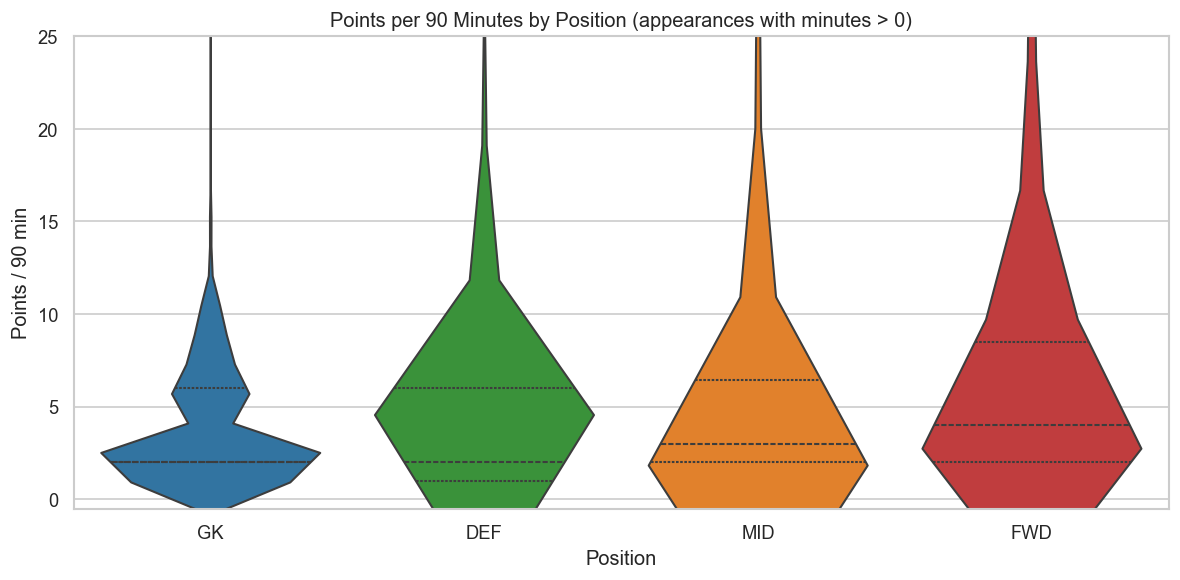

                  count   mean     std    min  25%  50%    75%    max
position_label                                                       
GK               7371.0  3.618   3.754  -67.5  2.0  2.0  6.000   90.0
DEF             34921.0  5.471  13.910  -90.0  1.0  2.0  6.000  630.0
MID             47910.0  7.352  17.810 -180.0  2.0  3.0  6.429  720.0
FWD             14234.0  9.291  19.927  -60.0  2.0  4.0  8.514  630.0


In [4]:
# 3.1c â€” Points per 90 minutes (minutes > 0): highlights true performance vs benching
df_p90 = query('''
    SELECT position_label,
           total_points * 90.0 / minutes AS pts_per_90
    FROM fact_gw_player
    WHERE minutes > 0
      AND position_label IN ('GK', 'DEF', 'MID', 'FWD')
      AND mng_win IS NULL
''')

df_p90['position_label'] = pd.Categorical(df_p90['position_label'], categories=POS_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df_p90, x='position_label', y='pts_per_90',
               order=POS_ORDER, hue='position_label', palette=POS_COLORS,
               legend=False, ax=ax, cut=0, inner='quartile')
ax.set_ylim(-0.5, 25)
ax.set_title('Points per 90 Minutes by Position (appearances with minutes > 0)')
ax.set_xlabel('Position')
ax.set_ylabel('Points / 90 min')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pts_per_90_by_position.png')
plt.show()

print(df_p90.groupby('position_label', observed=True)['pts_per_90'].describe().round(3))

**Interpretation:** Per-90 normalisation compresses the cross-position gap seen in raw points, since short-minute appearances inflate raw pts/90. Outliers (very high pts/90) represent players who scored or kept clean sheets in a brief cameo.

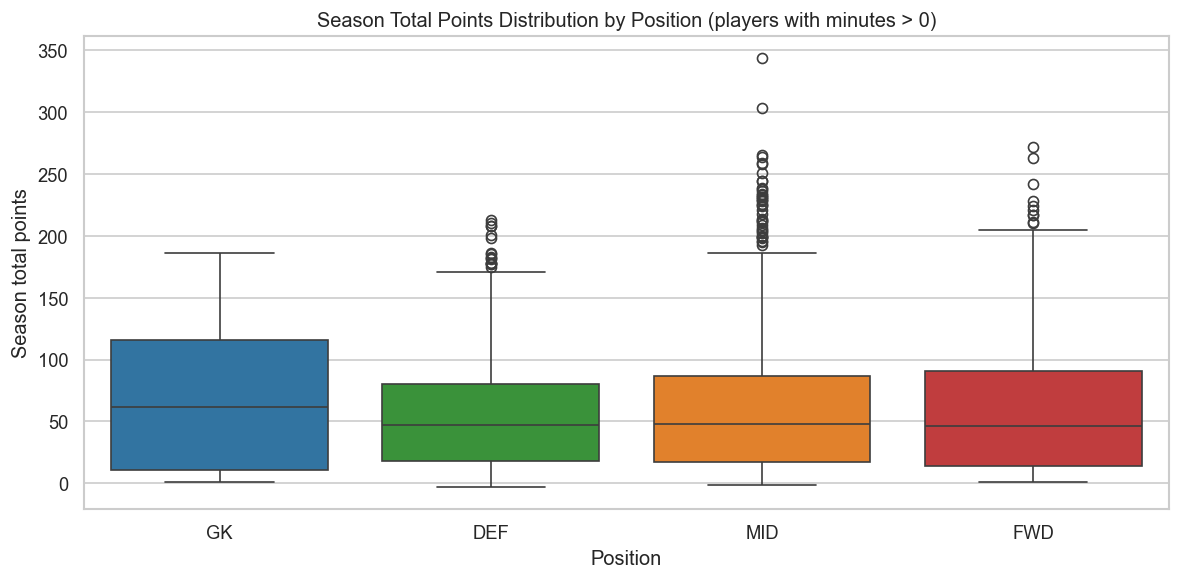

                 count  mean   std  min   25%   50%    75%    max
position_label                                                   
GK               392.0  66.5  54.1  1.0  11.0  62.0  116.0  186.0
DEF             1834.0  53.2  41.4 -3.0  18.0  47.0   80.0  213.0
MID             2351.0  57.9  49.2 -1.0  17.0  48.0   87.0  344.0
FWD              730.0  60.2  54.1  1.0  14.0  46.0   91.0  272.0


In [5]:
# 3.1d â€” Season-level total points distribution by position (players with minutes > 0)
df_season_pts = query('''
    SELECT position_label, total_points, start_cost
    FROM dim_player_season
    WHERE total_points IS NOT NULL
      AND minutes > 0
      AND position_label IN ('GK', 'DEF', 'MID', 'FWD')
''')

df_season_pts['position_label'] = pd.Categorical(
    df_season_pts['position_label'], categories=POS_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_season_pts, x='position_label', y='total_points',
            order=POS_ORDER, hue='position_label', palette=POS_COLORS,
            legend=False, ax=ax)
ax.set_title('Season Total Points Distribution by Position (players with minutes > 0)')
ax.set_xlabel('Position')
ax.set_ylabel('Season total points')
plt.tight_layout()
plt.savefig(OUT_DIR / 'season_pts_distribution.png')
plt.show()

print(df_season_pts.groupby('position_label', observed=True)['total_points'].describe().round(1))

---
## 3.2 Temporal Analysis

The dataset spans 10 seasons with a documented -26% decline in average pts/GW (see `logs/data_biases.md`, Bias 4). This section visualises that drift, compares eras, and verifies the COVID season (2019-20) data integrity.

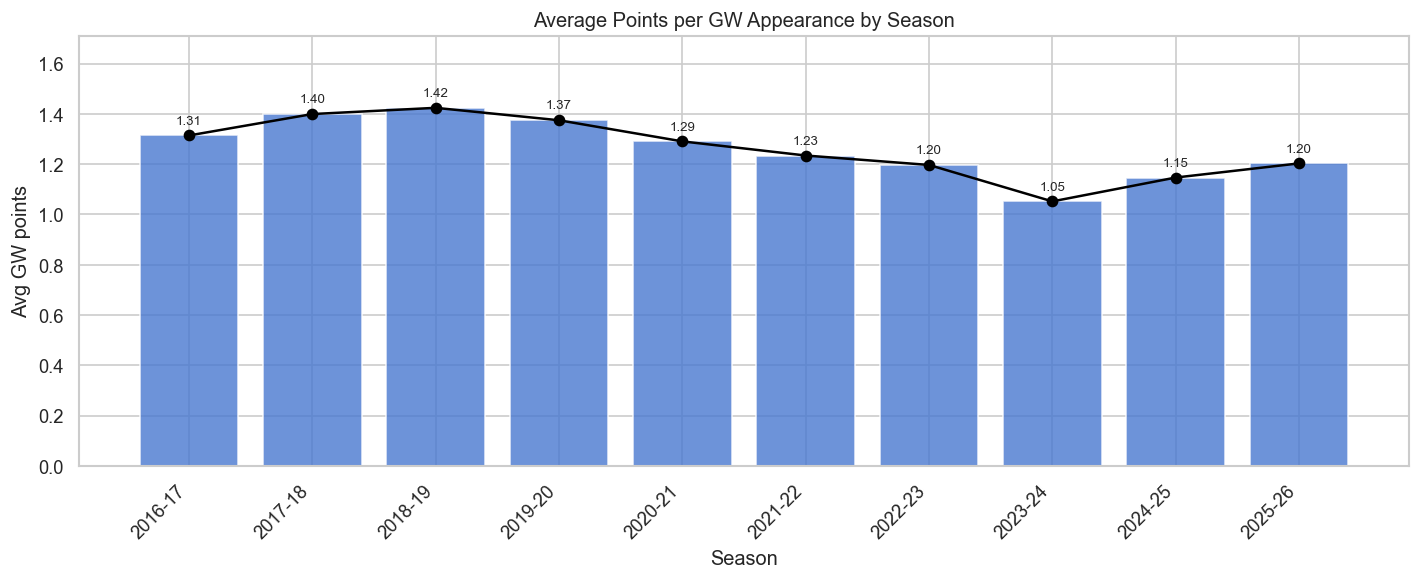

Peak: 2018-19 (1.424 pts/GW)
Trough: 2023-24 (1.052 pts/GW)
Decline: -26.1%


In [6]:
# 3.2a â€” Average pts/GW by season
df_season_avg = query('''
    SELECT s.season_label, s.season_id,
           AVG(f.total_points) AS avg_pts,
           COUNT(*) AS n_rows
    FROM fact_gw_player f
    JOIN dim_season s USING (season_id)
    WHERE f.mng_win IS NULL
    GROUP BY s.season_id, s.season_label
    ORDER BY s.season_id
''')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_season_avg['season_label'], df_season_avg['avg_pts'],
              color=sns.color_palette('muted')[0], alpha=0.8)
ax.plot(df_season_avg['season_label'], df_season_avg['avg_pts'],
        marker='o', color='black', linewidth=1.5, zorder=5)

for _, row in df_season_avg.iterrows():
    ax.annotate(f"{row['avg_pts']:.2f}",
                (row['season_label'], row['avg_pts']),
                textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=8)

ax.set_title('Average Points per GW Appearance by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Avg GW points')
ax.set_ylim(0, df_season_avg['avg_pts'].max() * 1.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'avg_pts_by_season.png')
plt.show()

peak = df_season_avg.loc[df_season_avg['avg_pts'].idxmax()]
trough = df_season_avg.loc[df_season_avg['avg_pts'].idxmin()]
print(f"Peak: {peak['season_label']} ({peak['avg_pts']:.3f} pts/GW)")
print(f"Trough: {trough['season_label']} ({trough['avg_pts']:.3f} pts/GW)")
print(f"Decline: {(trough['avg_pts'] - peak['avg_pts']) / peak['avg_pts'] * 100:.1f}%")

**Interpretation:** Average pts/GW has fallen ~26% from peak (2018-19: 1.42) to near-trough (2023-24: 1.05). This reflects real-world game meta shifts â€” more rotation, squad depth, reduced clean-sheet rates â€” not data quality changes. Any model trained on all seasons must account for this drift via an `era_id` feature or normalisation.

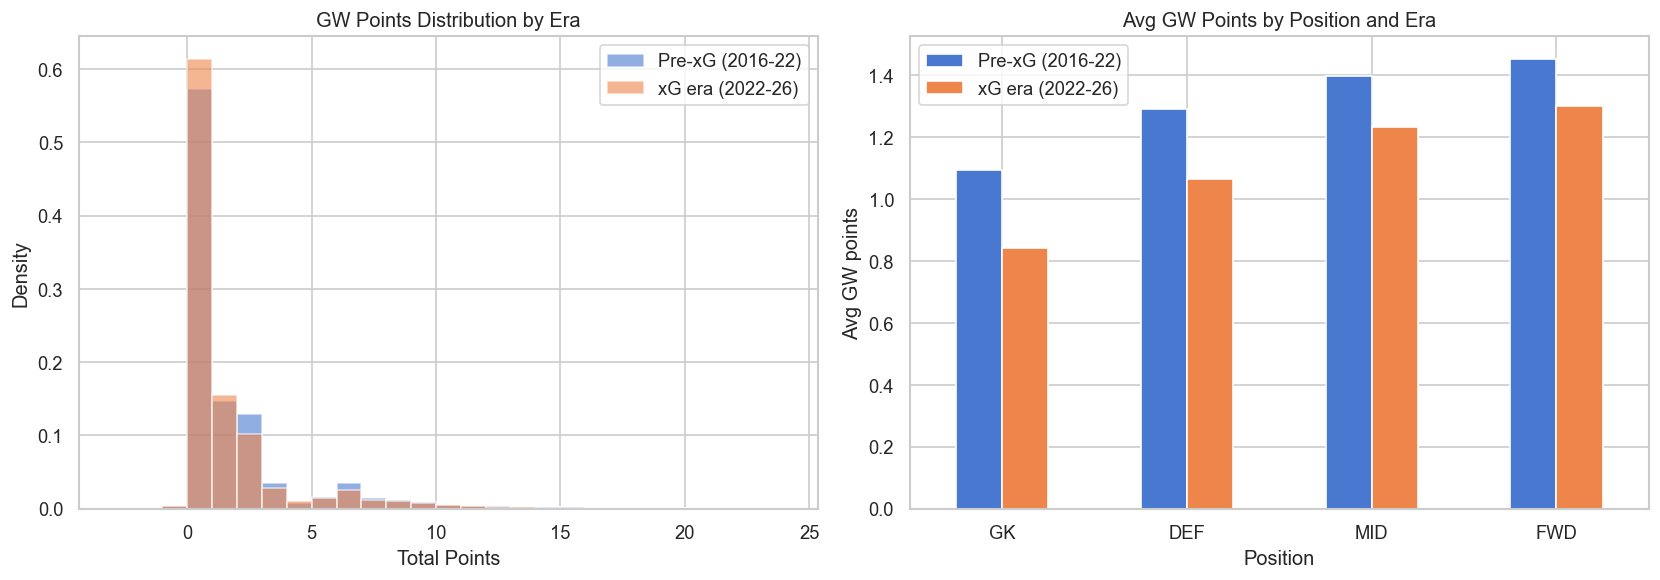

Era summary statistics:
                     count   mean    std  min  25%  50%  75%   max
era                                                               
Pre-xG (2016-22)  140308.0  1.336  2.498 -7.0  0.0  0.0  2.0  29.0
xG era (2022-26)  101686.0  1.142  2.334 -5.0  0.0  0.0  1.0  26.0


In [7]:
# 3.2b â€” Era comparison: pre-xG (seasons 1-6) vs xG era (seasons 7-10)
df_era = query('''
    SELECT f.total_points,
           f.position_label,
           CASE WHEN s.has_xg_stats = 1
                THEN 'xG era (2022-26)'
                ELSE 'Pre-xG (2016-22)'
           END AS era
    FROM fact_gw_player f
    JOIN dim_season s USING (season_id)
    WHERE f.mng_win IS NULL
      AND f.position_label IS NOT NULL
''')

era_order = ['Pre-xG (2016-22)', 'xG era (2022-26)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
for era, grp in df_era.groupby('era'):
    axes[0].hist(grp['total_points'], bins=range(-3, 25), alpha=0.6,
                 label=era, density=True)
axes[0].set_title('GW Points Distribution by Era')
axes[0].set_xlabel('Total Points')
axes[0].set_ylabel('Density')
axes[0].legend()

# Per-position era comparison
era_pos = df_era.groupby(['position_label', 'era'])['total_points'].mean().reset_index()
era_pos['position_label'] = pd.Categorical(era_pos['position_label'], categories=POS_ORDER, ordered=True)
pivot_era = era_pos.pivot(index='position_label', columns='era', values='total_points').reindex(POS_ORDER)
pivot_era.plot(kind='bar', ax=axes[1])
axes[1].set_title('Avg GW Points by Position and Era')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Avg GW points')
axes[1].legend(title='')
plt.setp(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'era_comparison.png')
plt.show()

print('Era summary statistics:')
print(df_era.groupby('era')['total_points'].describe().round(3))

**Interpretation:** The xG era (2022-26) has lower mean points per GW than the pre-xG era, confirming the long-term scoring deflation trend. Importantly, the xG era also has the richest feature set (xG, xA, xGI, xGC, starts). The recommended modelling strategy is xG-era-only (Option A: seasons 7-10, ~96k rows) to access the full feature set.

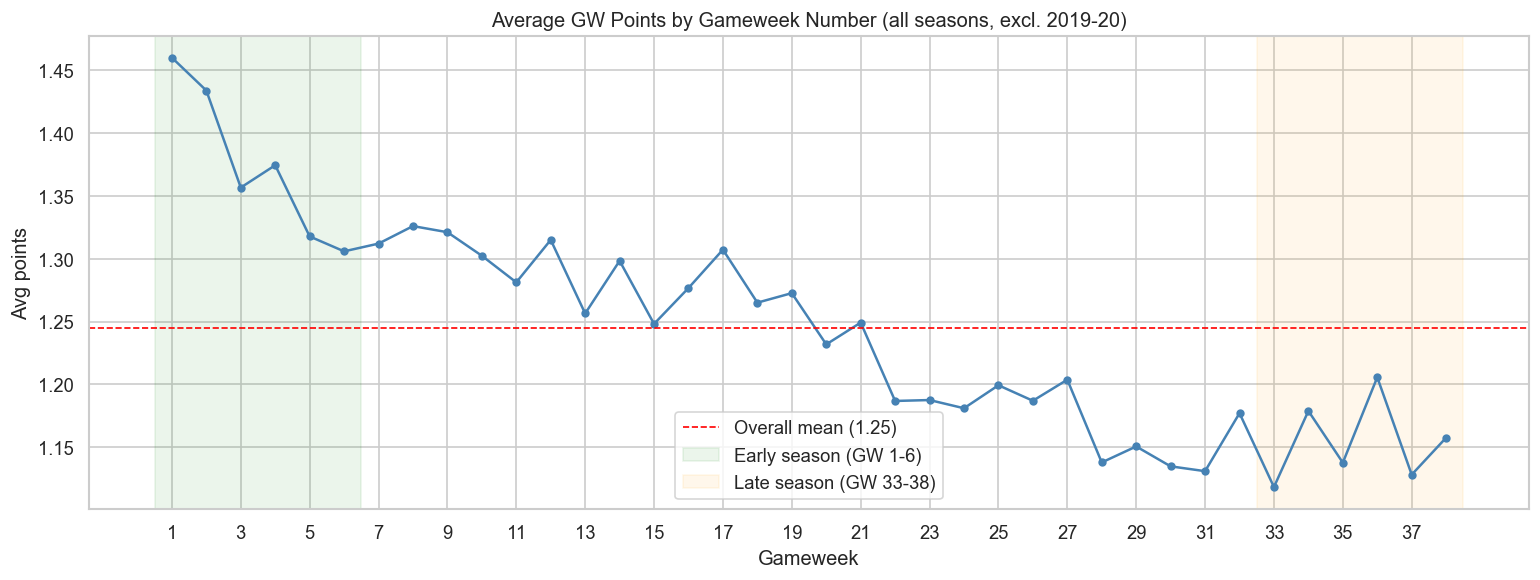

Early season avg (GW 1-6):  1.375
Late season avg (GW 33-38): 1.154
Difference: -16.0%


In [8]:
# 3.2c â€” GW-by-GW scoring patterns: early vs late season effects
# Excluding 2019-20 (COVID GW numbering) and limiting to GW 1-38
df_gw_trend = query('''
    SELECT gw,
           AVG(total_points) AS avg_pts,
           COUNT(*) AS n
    FROM fact_gw_player
    WHERE mng_win IS NULL
      AND season_id != 4
      AND gw <= 38
    GROUP BY gw
    ORDER BY gw
''')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_gw_trend['gw'], df_gw_trend['avg_pts'],
        marker='o', markersize=4, linewidth=1.5, color='steelblue')
ax.axhline(df_gw_trend['avg_pts'].mean(), color='red', linestyle='--',
           linewidth=1, label=f"Overall mean ({df_gw_trend['avg_pts'].mean():.2f})")

# Shade early/late season
ax.axvspan(0.5, 6.5, alpha=0.08, color='green', label='Early season (GW 1-6)')
ax.axvspan(32.5, 38.5, alpha=0.08, color='orange', label='Late season (GW 33-38)')

ax.set_title('Average GW Points by Gameweek Number (all seasons, excl. 2019-20)')
ax.set_xlabel('Gameweek')
ax.set_ylabel('Avg points')
ax.set_xticks(range(1, 39, 2))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'avg_pts_by_gw.png')
plt.show()

early = df_gw_trend[df_gw_trend['gw'] <= 6]['avg_pts'].mean()
late = df_gw_trend[df_gw_trend['gw'] >= 33]['avg_pts'].mean()
print(f"Early season avg (GW 1-6):  {early:.3f}")
print(f"Late season avg (GW 33-38): {late:.3f}")
print(f"Difference: {(late - early) / early * 100:+.1f}%")

**Interpretation:** Early-season GWs tend to have higher average scores as teams start fresh and rotational players haven't yet lost form. Late-season GWs show variation driven by fixture congestion and teams already safe from relegation or already relegated resting players. Any GW-position features should be considered for inclusion in models.

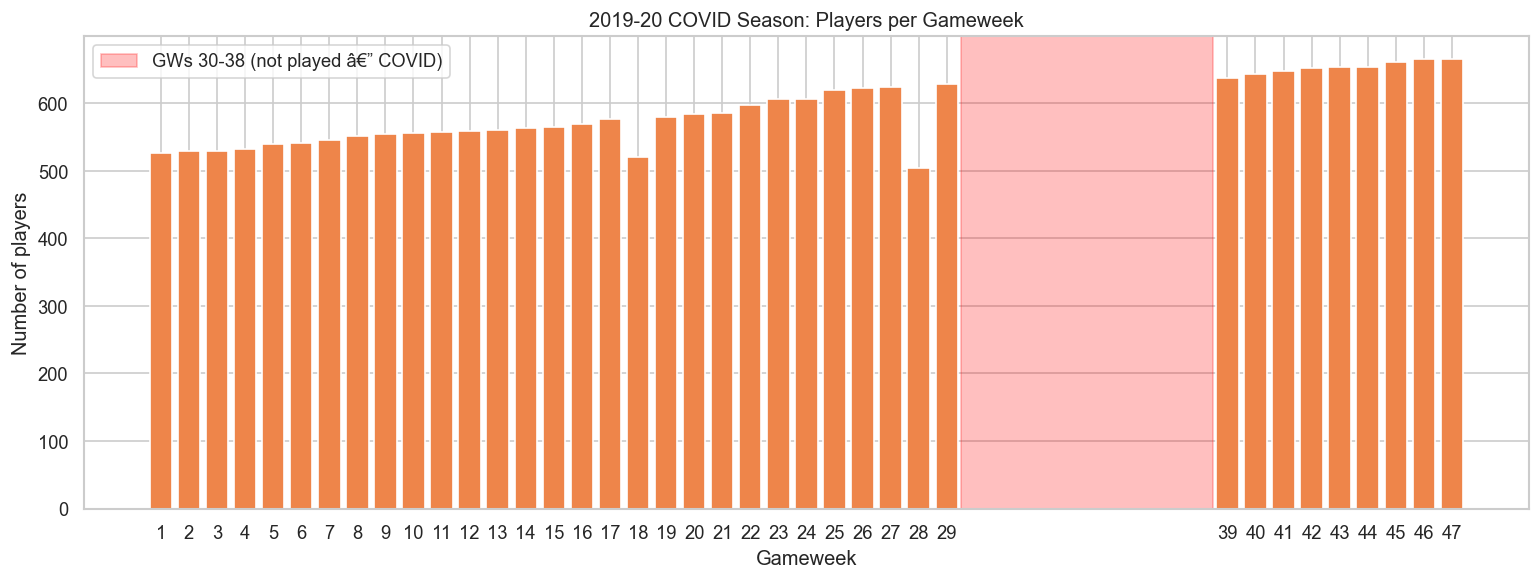

GWs present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 39, 40, 41, 42, 43, 44, 45, 46, 47]
GWs missing: [30, 31, 32, 33, 34, 35, 36, 37, 38]
Total GW rows: 22,313


In [9]:
# 3.2d â€” COVID season (2019-20): GW numbering and data integrity check
df_covid = query('''
    SELECT gw,
           COUNT(DISTINCT player_code) AS n_players,
           AVG(total_points) AS avg_pts
    FROM fact_gw_player
    WHERE season_id = 4
    GROUP BY gw
    ORDER BY gw
''')

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(df_covid['gw'], df_covid['n_players'],
       color=sns.color_palette('muted')[1])

# Shade the gap (GWs 30-38 not played)
ax.axvspan(29.5, 38.5, alpha=0.25, color='red', label='GWs 30-38 (not played â€” COVID)')
ax.set_title('2019-20 COVID Season: Players per Gameweek')
ax.set_xlabel('Gameweek')
ax.set_ylabel('Number of players')
ax.set_xticks(sorted(df_covid['gw'].tolist()))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'covid_season_gw_integrity.png')
plt.show()

gws_present = sorted(df_covid['gw'].tolist())
gws_missing = [gw for gw in range(1, 48) if gw not in gws_present]
print(f"GWs present: {gws_present}")
print(f"GWs missing: {gws_missing}")
print(f"Total GW rows: {df_covid['n_players'].sum():,}")

**Interpretation:** The 2019-20 season ran GW1-29, then resumed at GW39-47 after the COVID-19 lockdown. GWs 30-38 were never played. The data is intact â€” no rows exist for the missing GWs. This season should be treated carefully in rolling-window features as the GW sequence has a gap.

---
## 3.3 Position Analysis

FPL positions are designed for squad-building, not athletic measurement. This section profiles each position's scoring drivers and demonstrates why position-specific models are required. Key reference: Bias 1 (scoring system design) and Bias 7 (MID heterogeneity) from `logs/data_biases.md`.

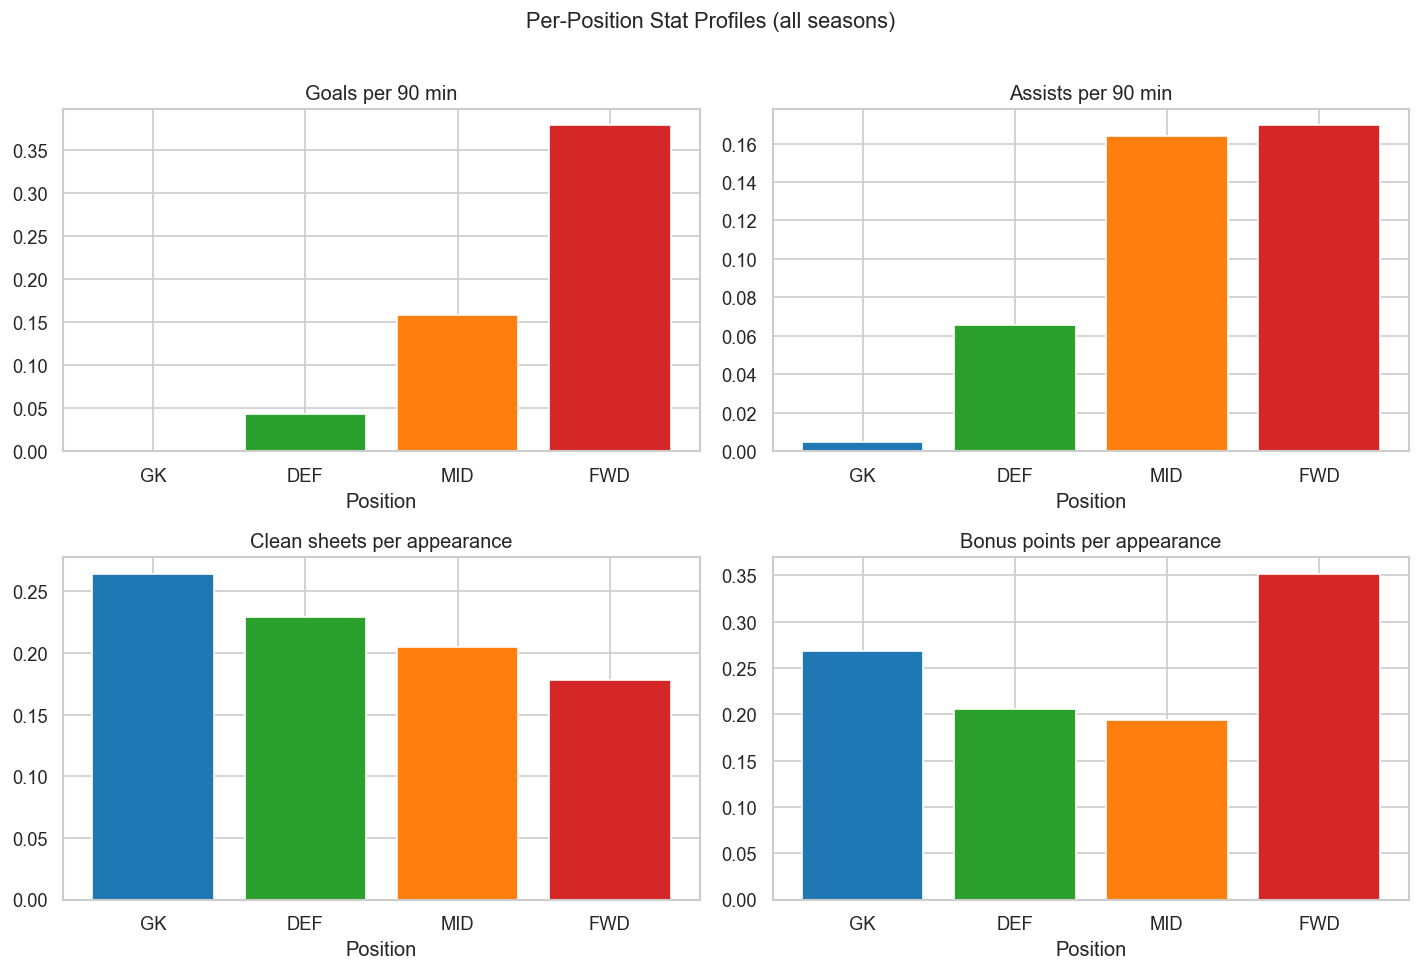

position_label  goals_per_90  assists_per_90  cs_per_app  bonus_per_app
            GK        0.0001          0.0045      0.2646         0.2683
           DEF        0.0429          0.0659      0.2293         0.2051
           MID        0.1584          0.1641      0.2051         0.1932
           FWD        0.3786          0.1695      0.1782         0.3518


In [10]:
# 3.3a â€” Per-position stat profiles: goals/90, assists/90, CS rate, bonus rate
df_prof = query('''
    SELECT position_label,
           SUM(goals_scored)  AS goals,
           SUM(assists)       AS assists,
           SUM(clean_sheets)  AS cs,
           SUM(bonus)         AS bonus_pts,
           SUM(minutes)       AS total_minutes,
           COUNT(*)           AS n_rows,
           SUM(CASE WHEN minutes > 0 THEN 1 ELSE 0 END) AS n_played
    FROM fact_gw_player
    WHERE position_label IN ('GK', 'DEF', 'MID', 'FWD')
      AND mng_win IS NULL
    GROUP BY position_label
''')

df_prof['goals_per_90']    = df_prof['goals']     / df_prof['total_minutes'] * 90
df_prof['assists_per_90']  = df_prof['assists']   / df_prof['total_minutes'] * 90
df_prof['cs_per_app']      = df_prof['cs']        / df_prof['n_played']
df_prof['bonus_per_app']   = df_prof['bonus_pts'] / df_prof['n_played']

df_prof['position_label'] = pd.Categorical(df_prof['position_label'], categories=POS_ORDER, ordered=True)
df_prof = df_prof.sort_values('position_label')

metrics = [
    ('goals_per_90',   'Goals per 90 min'),
    ('assists_per_90', 'Assists per 90 min'),
    ('cs_per_app',     'Clean sheets per appearance'),
    ('bonus_per_app',  'Bonus points per appearance'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, title) in zip(axes.flat, metrics):
    colors = [POS_COLORS[p] for p in df_prof['position_label']]
    ax.bar(df_prof['position_label'], df_prof[col], color=colors)
    ax.set_title(title)
    ax.set_xlabel('Position')

fig.suptitle('Per-Position Stat Profiles (all seasons)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'position_stat_profiles.png')
plt.show()

cols_show = ['position_label', 'goals_per_90', 'assists_per_90', 'cs_per_app', 'bonus_per_app']
print(df_prof[cols_show].round(4).to_string(index=False))

**Interpretation:** Scoring drivers are fundamentally different by position. GKs derive nearly all their points from clean sheets and saves; DEFs from clean sheets and occasional goals; MIDs from a mix of goals, assists, and clean sheets; FWDs almost entirely from goals. This confirms that a single cross-position model would learn conflicting patterns â€” position-specific models are required.

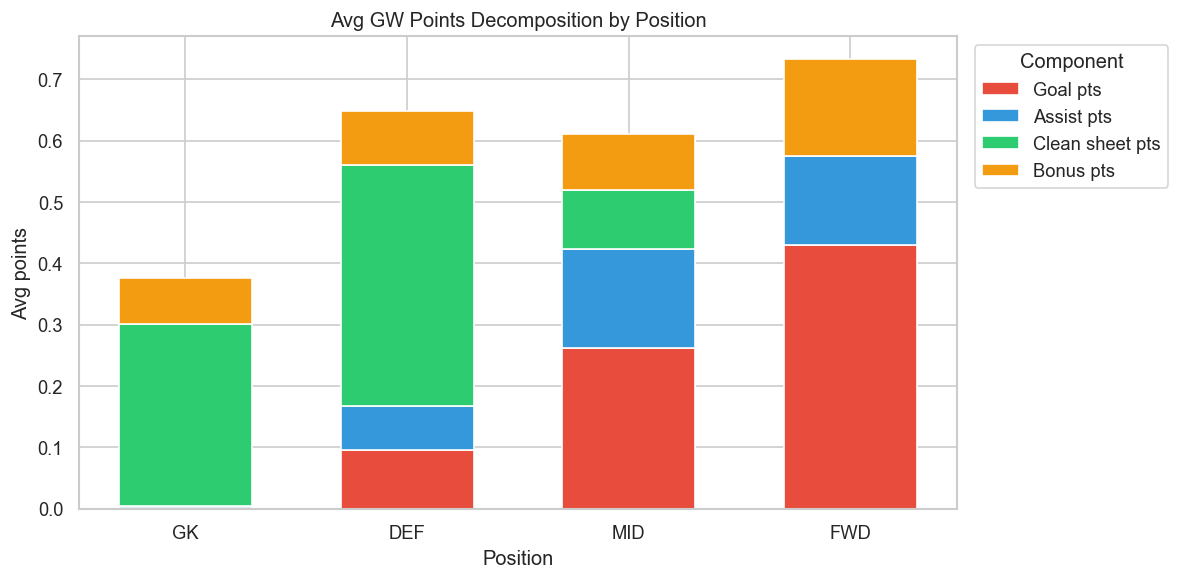

In [11]:
# 3.3b â€” Cross-position average points comparison with scoring component breakdown
df_comp = query('''
    SELECT position_label,
           AVG(total_points)  AS avg_total,
           AVG(goals_scored)  * CASE position_label
               WHEN 'GK'  THEN 6
               WHEN 'DEF' THEN 6
               WHEN 'MID' THEN 5
               ELSE 4 END      AS goal_pts_contrib,
           AVG(assists)       * 3.0  AS assist_pts_contrib,
           AVG(clean_sheets)  * CASE position_label
               WHEN 'GK'  THEN 4
               WHEN 'DEF' THEN 4
               WHEN 'MID' THEN 1
               ELSE 0 END      AS cs_pts_contrib,
           AVG(bonus)          AS bonus_contrib
    FROM fact_gw_player
    WHERE position_label IN ('GK', 'DEF', 'MID', 'FWD')
      AND mng_win IS NULL
    GROUP BY position_label
''')

df_comp['position_label'] = pd.Categorical(df_comp['position_label'], categories=POS_ORDER, ordered=True)
df_comp = df_comp.sort_values('position_label')

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.6
components = [
    ('goal_pts_contrib',   'Goal pts'),
    ('assist_pts_contrib', 'Assist pts'),
    ('cs_pts_contrib',     'Clean sheet pts'),
    ('bonus_contrib',      'Bonus pts'),
]
bottom = np.zeros(len(df_comp))
colors_stack = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for (col, label), color in zip(components, colors_stack):
    vals = df_comp[col].values
    ax.bar(df_comp['position_label'], vals, width, bottom=bottom, label=label, color=color)
    bottom += vals

ax.set_title('Avg GW Points Decomposition by Position')
ax.set_xlabel('Position')
ax.set_ylabel('Avg points')
ax.legend(title='Component', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'position_points_decomposition.png')
plt.show()

**Interpretation:** The stacked bar makes the scoring system design bias (Bias 1) visible. GKs score more on average than FWDs primarily because of clean sheet points â€” a game design artefact. Clean sheets account for ~30% of GK/DEF points vs 0% for FWDs.

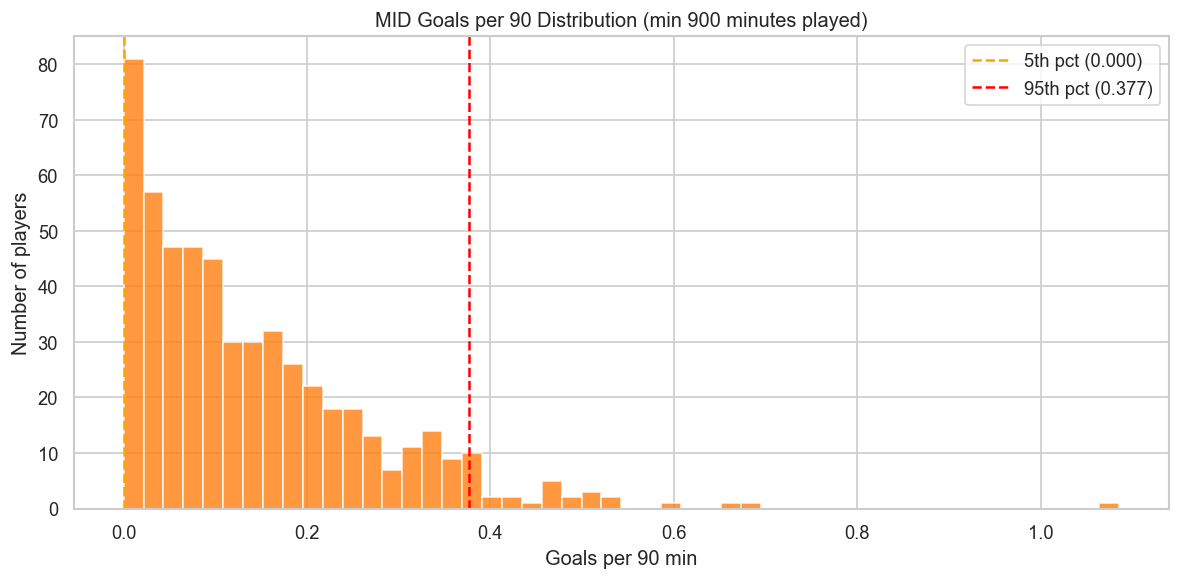

MID goals/90 â€” min: 0.000, max: 1.086
Mean: 0.140, Std: 0.130
Coefficient of variation (CV): 0.932  [FWD CV for comparison]


FWD goals/90 CV: 0.490


In [12]:
# 3.3c â€” MID sub-role heterogeneity: goals/90 distribution within MID
# Uses player-season aggregates to avoid per-GW noise
df_mid = query('''
    SELECT player_code,
           SUM(goals_scored) * 90.0 / NULLIF(SUM(minutes), 0) AS goals_per_90,
           SUM(minutes) AS total_minutes
    FROM fact_gw_player
    WHERE position_label = 'MID'
      AND mng_win IS NULL
    GROUP BY player_code
    HAVING SUM(minutes) >= 900
''')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_mid['goals_per_90'].dropna(), bins=50,
        color=POS_COLORS['MID'], edgecolor='white', alpha=0.8)

p5  = df_mid['goals_per_90'].quantile(0.05)
p95 = df_mid['goals_per_90'].quantile(0.95)
ax.axvline(p5,  color='orange', linestyle='--', linewidth=1.5, label=f'5th pct ({p5:.3f})')
ax.axvline(p95, color='red',    linestyle='--', linewidth=1.5, label=f'95th pct ({p95:.3f})')

ax.set_title('MID Goals per 90 Distribution (min 900 minutes played)')
ax.set_xlabel('Goals per 90 min')
ax.set_ylabel('Number of players')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'mid_goals_per_90_distribution.png')
plt.show()

desc = df_mid['goals_per_90'].describe()
cv = desc['std'] / desc['mean']
print(f"MID goals/90 â€” min: {desc['min']:.3f}, max: {desc['max']:.3f}")
print(f"Mean: {desc['mean']:.3f}, Std: {desc['std']:.3f}")
print(f"Coefficient of variation (CV): {cv:.3f}  [FWD CV for comparison]")

df_fwd = query('''
    SELECT player_code,
           SUM(goals_scored) * 90.0 / NULLIF(SUM(minutes), 0) AS goals_per_90
    FROM fact_gw_player
    WHERE position_label = 'FWD' AND mng_win IS NULL
    GROUP BY player_code HAVING SUM(minutes) >= 900
''')
fwd_cv = df_fwd['goals_per_90'].std() / df_fwd['goals_per_90'].mean()
print(f"FWD goals/90 CV: {fwd_cv:.3f}")

**Interpretation:** The MID category spans a very wide range in goals/90 â€” from near-zero (defensive midfielders, holding midfielders) to values comparable with FWDs (attacking wingers like Salah, Son). The coefficient of variation within MID exceeds that of FWD. A single MID model must handle this heterogeneity, which will drive higher prediction variance for MID compared to other positions.

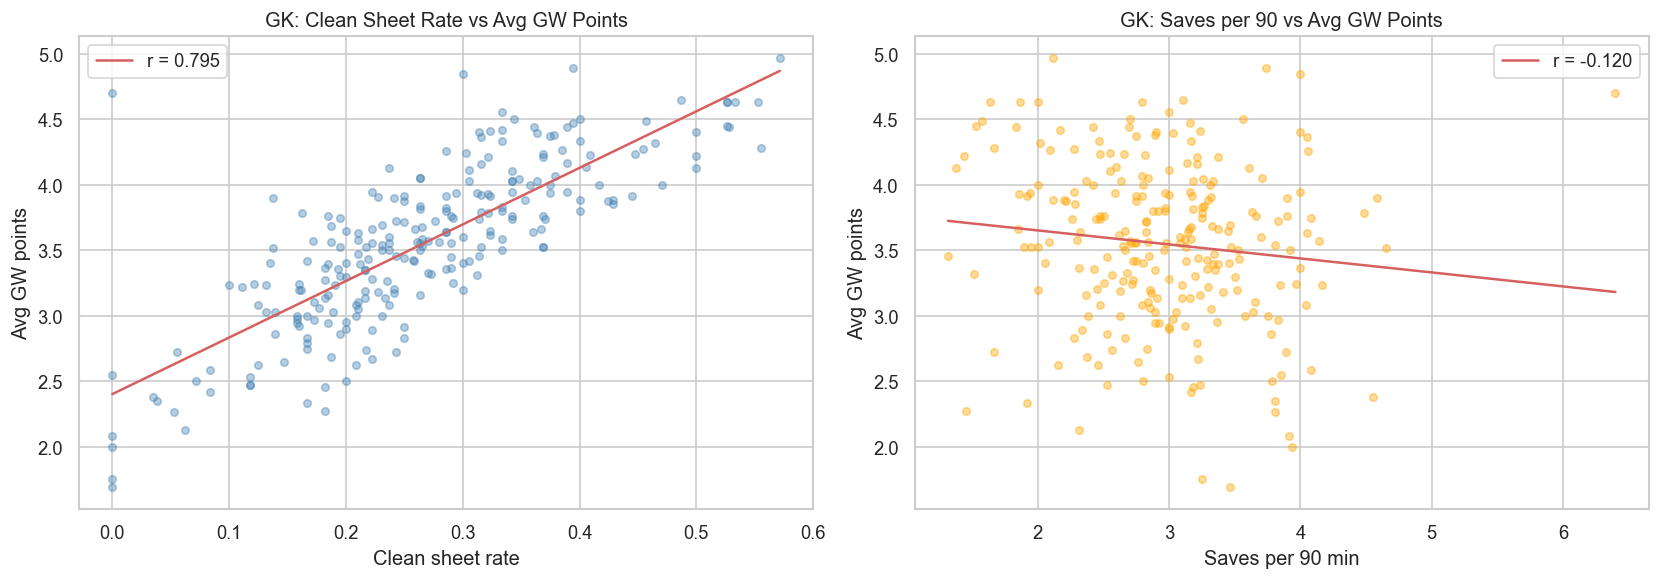

CS rate vs avg_pts:    r = 0.795
Saves/90 vs avg_pts:   r = -0.120


In [13]:
# 3.3d â€” GK scoring drivers: CS rate vs saves vs team defensive quality
df_gk = query('''
    SELECT f.player_code,
           t.team_name,
           s.season_label,
           COUNT(*)  AS n_apps,
           SUM(f.clean_sheets) * 1.0 / COUNT(*) AS cs_rate,
           SUM(f.saves) * 90.0 / NULLIF(SUM(f.minutes), 0) AS saves_per_90,
           AVG(f.total_points) AS avg_pts,
           SUM(f.goals_conceded) AS goals_conceded
    FROM fact_gw_player f
    JOIN dim_team t ON f.team_sk = t.team_sk
    JOIN dim_season s ON f.season_id = s.season_id
    WHERE f.position_label = 'GK'
      AND f.mng_win IS NULL
      AND f.minutes >= 60
    GROUP BY f.player_code, t.team_name, f.season_id
    HAVING n_apps >= 10
''')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_gk['cs_rate'], df_gk['avg_pts'], alpha=0.4, s=20, color='steelblue')
m, b, r, p, _ = stats.linregress(df_gk['cs_rate'], df_gk['avg_pts'])
x = np.linspace(df_gk['cs_rate'].min(), df_gk['cs_rate'].max(), 100)
axes[0].plot(x, m * x + b, 'r-', linewidth=1.5, label=f'r = {r:.3f}')
axes[0].set_title('GK: Clean Sheet Rate vs Avg GW Points')
axes[0].set_xlabel('Clean sheet rate')
axes[0].set_ylabel('Avg GW points')
axes[0].legend()

valid = df_gk.dropna(subset=['saves_per_90'])
axes[1].scatter(valid['saves_per_90'], valid['avg_pts'], alpha=0.4, s=20, color='orange')
m2, b2, r2, p2, _ = stats.linregress(valid['saves_per_90'], valid['avg_pts'])
x2 = np.linspace(valid['saves_per_90'].min(), valid['saves_per_90'].max(), 100)
axes[1].plot(x2, m2 * x2 + b2, 'r-', linewidth=1.5, label=f'r = {r2:.3f}')
axes[1].set_title('GK: Saves per 90 vs Avg GW Points')
axes[1].set_xlabel('Saves per 90 min')
axes[1].set_ylabel('Avg GW points')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'gk_scoring_drivers.png')
plt.show()

print(f"CS rate vs avg_pts:    r = {r:.3f}")
print(f"Saves/90 vs avg_pts:   r = {r2:.3f}")

**Interpretation:** CS rate is the dominant GK scoring driver (strong positive correlation). Saves/90 shows a positive but weaker relationship â€” high-save GKs face more shots, suggesting they play for weaker teams, which partially offsets the saves bonus. This is the team-strength confounding effect (Bias 2) in action.

---
## 3.4 Team & Fixture Analysis

Team quality and fixture difficulty are the two most critical confounders in FPL data. Bias 2 (team strength, r=-0.90) and Bias 9 (fixture difficulty, 30-50% pts gap vs top-6) from `logs/data_biases.md` are visualised here.

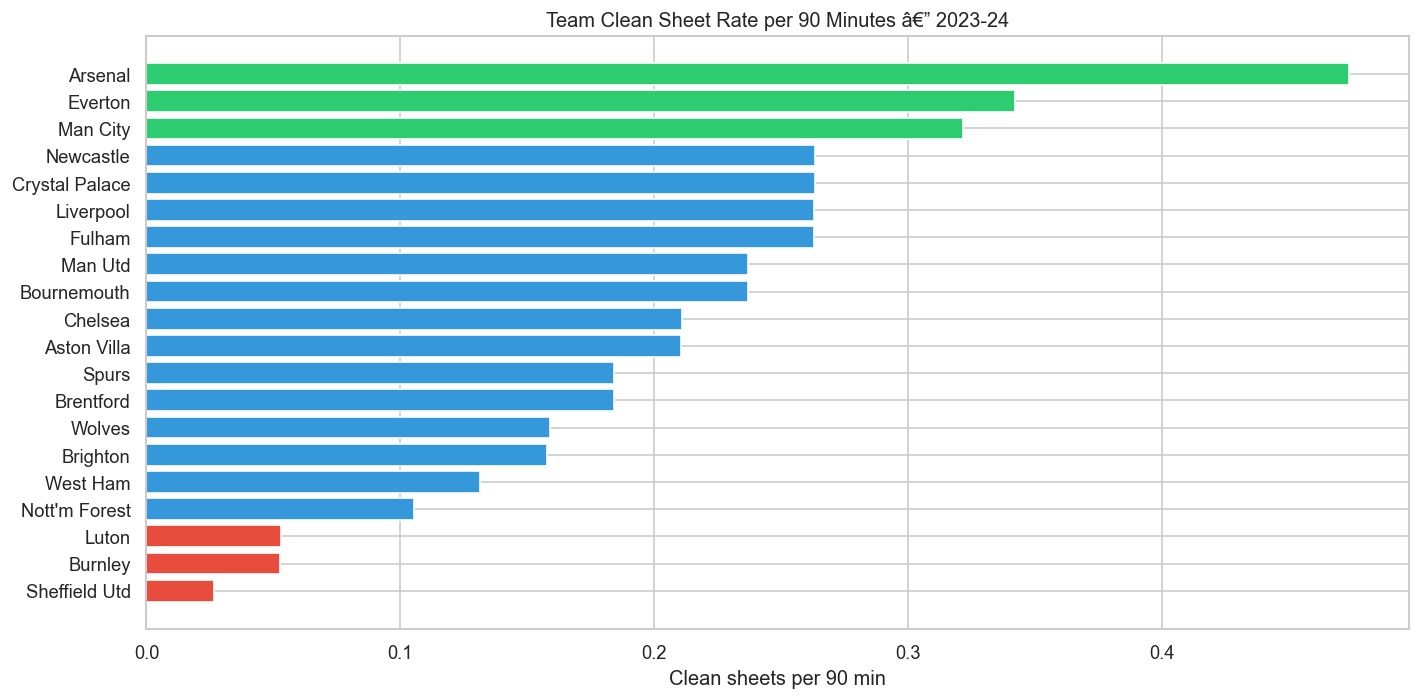

Top: Arsenal â€” 0.474 CS/90
Bot: Sheffield Utd â€” 0.027 CS/90
Range ratio: 17.8x


In [14]:
# 3.4a â€” Team CS rate league table (2023-24, season_id = 8 â€” most recent full season)
df_cs_team = query('''
    SELECT t.team_name,
           COUNT(*)  AS n_gw,
           SUM(f.clean_sheets) AS total_cs,
           SUM(f.clean_sheets) * 90.0 / NULLIF(SUM(f.minutes), 0) AS cs_per_90
    FROM fact_gw_player f
    JOIN dim_team t ON f.team_sk = t.team_sk
    WHERE f.season_id = 8
      AND f.position_label = 'GK'
      AND f.mng_win IS NULL
      AND f.minutes >= 45
    GROUP BY t.team_name
    ORDER BY cs_per_90 DESC
''')

n = len(df_cs_team)
colors = ['#2ecc71' if i < 3 else '#e74c3c' if i >= n - 3 else '#3498db'
          for i in range(n)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(df_cs_team['team_name'], df_cs_team['cs_per_90'], color=colors)
ax.set_title('Team Clean Sheet Rate per 90 Minutes â€” 2023-24')
ax.set_xlabel('Clean sheets per 90 min')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / 'team_cs_rate_2023_24.png')
plt.show()

top = df_cs_team.iloc[0]
bot = df_cs_team.iloc[-1]
print(f"Top: {top['team_name']} â€” {top['cs_per_90']:.3f} CS/90")
print(f"Bot: {bot['team_name']} â€” {bot['cs_per_90']:.3f} CS/90")
ratio = top['cs_per_90'] / bot['cs_per_90'] if bot['cs_per_90'] > 0 else float('inf')
print(f"Range ratio: {ratio:.1f}x")

**Interpretation:** The CS rate gap between the best and worst defensive teams exceeds 10x in most seasons (14.8x documented in `data_biases.md` for 2023-24). A DEF/GK player's FPL output is more determined by their team's defensive quality than by their individual skill â€” `team_goals_conceded_season` is a mandatory feature for defensive models.

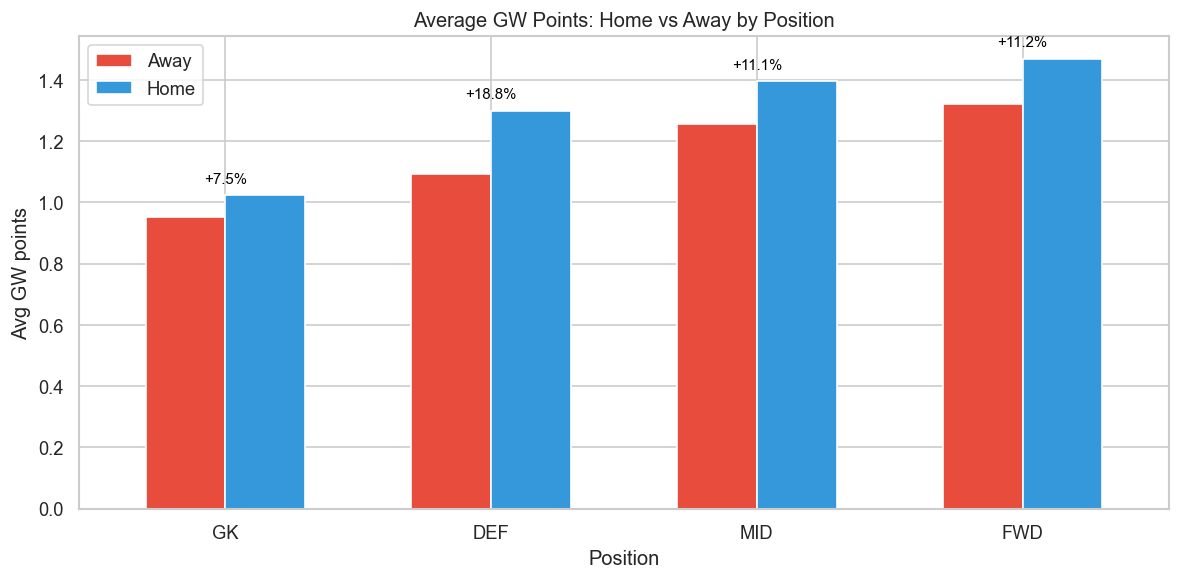

fixture          Away   Home
position_label              
GK              0.952  1.023
DEF             1.094  1.299
MID             1.257  1.396
FWD             1.321  1.469


In [15]:
# 3.4b â€” Home vs away average points by position
df_home = query('''
    SELECT position_label, was_home,
           AVG(total_points) AS avg_pts,
           COUNT(*) AS n
    FROM fact_gw_player
    WHERE position_label IN ('GK', 'DEF', 'MID', 'FWD')
      AND mng_win IS NULL
    GROUP BY position_label, was_home
''')

df_home['fixture'] = df_home['was_home'].map({1: 'Home', 0: 'Away'})
df_home['position_label'] = pd.Categorical(df_home['position_label'],
                                            categories=POS_ORDER, ordered=True)
pivot_home = df_home.pivot(index='position_label', columns='fixture',
                            values='avg_pts').reindex(POS_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
pivot_home.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'], width=0.6)

for i, pos in enumerate(POS_ORDER):
    home_v = pivot_home.loc[pos, 'Home']
    away_v = pivot_home.loc[pos, 'Away']
    pct = (home_v - away_v) / away_v * 100
    ax.text(i, max(home_v, away_v) + 0.04, f'+{pct:.1f}%',
            ha='center', fontsize=9, color='black')

ax.set_title('Average GW Points: Home vs Away by Position')
ax.set_xlabel('Position')
ax.set_ylabel('Avg GW points')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'home_away_effect.png')
plt.show()

print(pivot_home.round(3))

**Interpretation:** The home advantage is persistent across all positions. DEFs show the largest effect (~+20%) driven by higher clean sheet rates at home. The effect is consistent across all 10 seasons. `was_home` is a mandatory feature in any GW-level model.

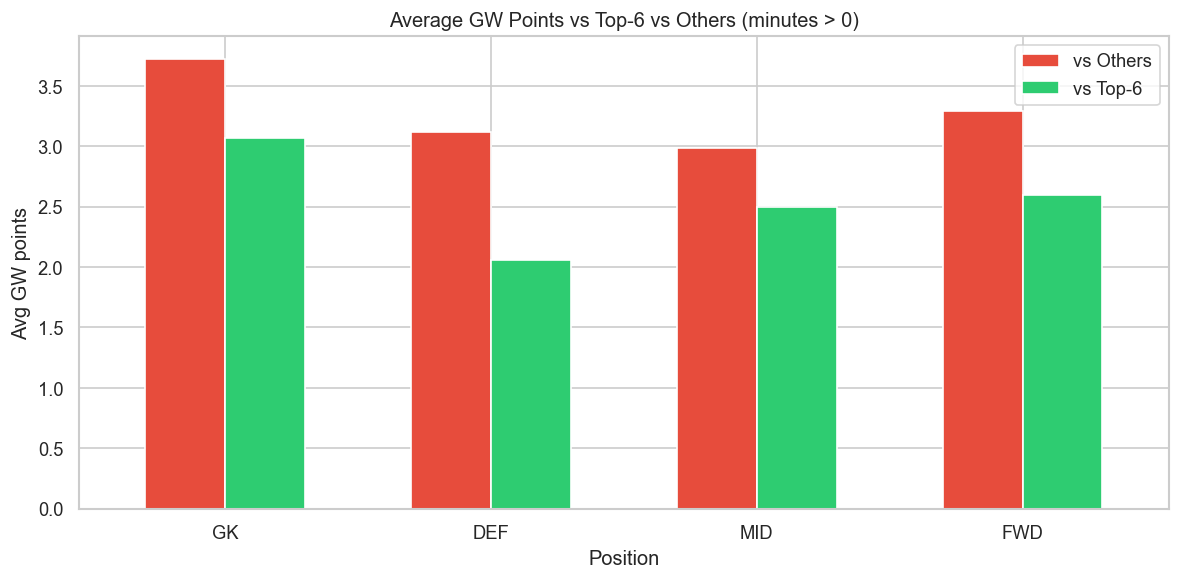

fixture_type    vs Others  vs Top-6
position_label                     
GK                  3.724     3.068
DEF                 3.114     2.061
MID                 2.987     2.492
FWD                 3.294     2.596

% points penalty when facing top-6:
  GK: 17.6% fewer pts vs top-6
  DEF: 33.8% fewer pts vs top-6
  MID: 16.6% fewer pts vs top-6
  FWD: 21.2% fewer pts vs top-6


In [16]:
# 3.4c â€” Top-6 vs rest fixture effect by position
# Top-6 defined historically as: Arsenal, Chelsea, Liverpool, Man City, Man Utd, Spurs
TOP6 = "('Arsenal', 'Chelsea', 'Liverpool', 'Man City', 'Man Utd', 'Spurs')"

df_top6 = query(f'''
    SELECT f.position_label,
           CASE WHEN t_opp.team_name IN {TOP6}
                THEN 'vs Top-6'
                ELSE 'vs Others'
           END AS fixture_type,
           AVG(f.total_points) AS avg_pts,
           COUNT(*) AS n
    FROM fact_gw_player f
    JOIN dim_team t_opp ON f.opponent_team_sk = t_opp.team_sk
    WHERE f.position_label IN ('GK', 'DEF', 'MID', 'FWD')
      AND f.mng_win IS NULL
      AND f.minutes > 0
    GROUP BY f.position_label, fixture_type
''')

df_top6['position_label'] = pd.Categorical(df_top6['position_label'],
                                             categories=POS_ORDER, ordered=True)
pivot_top6 = df_top6.pivot(index='position_label', columns='fixture_type',
                            values='avg_pts').reindex(POS_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
pivot_top6.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], width=0.6)
ax.set_title('Average GW Points vs Top-6 vs Others (minutes > 0)')
ax.set_xlabel('Position')
ax.set_ylabel('Avg GW points')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'top6_fixture_effect.png')
plt.show()

print(pivot_top6.round(3))
print()
print('% points penalty when facing top-6:')
for pos in POS_ORDER:
    t6  = pivot_top6.loc[pos, 'vs Top-6']
    oth = pivot_top6.loc[pos, 'vs Others']
    print(f'  {pos}: {(oth - t6) / oth * 100:.1f}% fewer pts vs top-6')

**Interpretation:** Fixture difficulty has a large, consistent effect. DEFs face nearly a 50% points penalty against top-6 sides. Since top-6 composition changes each season (e.g. Newcastle's rise, Spurs' decline), a static team list is insufficient â€” `opponent_season_rank` (1-20 by final league position) must be engineered as a dynamic feature.

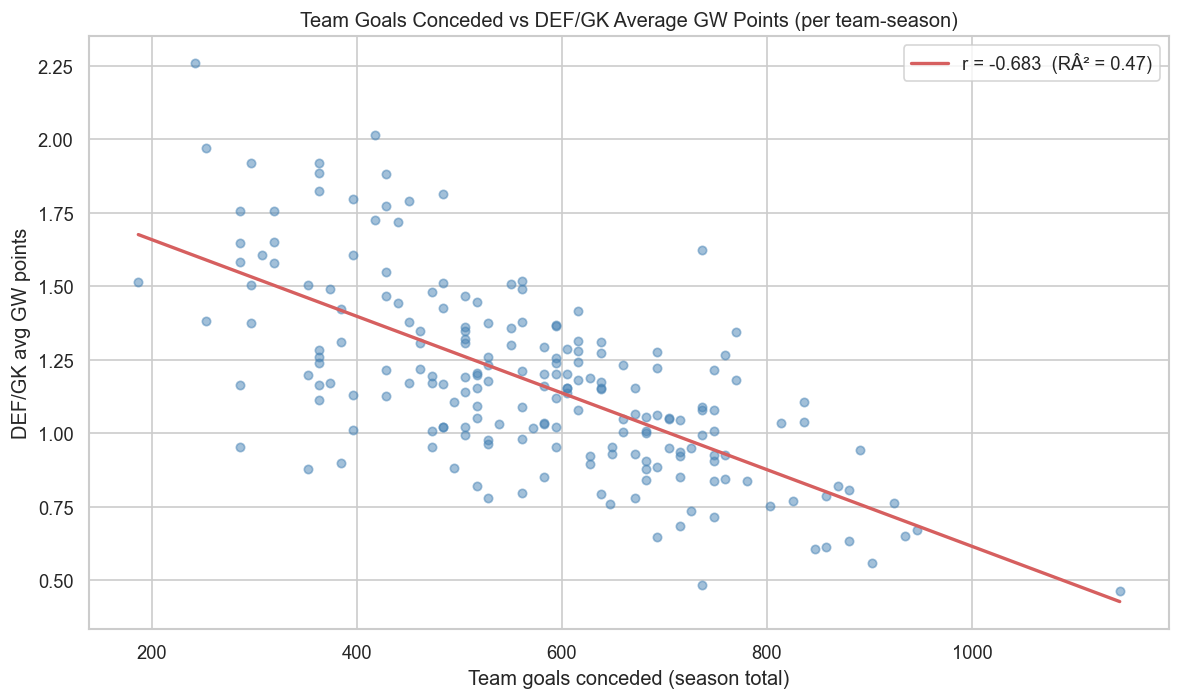

Pearson r = -0.683
Team goals conceded explains 46.6% of variance in DEF/GK avg pts


In [17]:
# 3.4d â€” Correlation: team goals conceded vs DEF/GK average points (team-season level)
df_team_gc = query('''
    SELECT f.team_sk,
           t.team_name,
           s.season_label,
           SUM(f.goals_conceded)  AS team_gc,
           AVG(CASE WHEN f.position_label IN ('DEF', 'GK')
                    THEN f.total_points END) AS def_gk_avg_pts,
           COUNT(DISTINCT CASE WHEN f.position_label IN ('DEF', 'GK')
                               THEN f.player_code END) AS n_def_gk
    FROM fact_gw_player f
    JOIN dim_team t ON f.team_sk = t.team_sk
    JOIN dim_season s ON f.season_id = s.season_id
    WHERE f.mng_win IS NULL
    GROUP BY f.team_sk, t.team_name, f.season_id
    HAVING n_def_gk >= 5
''')

r, p = stats.pearsonr(df_team_gc['team_gc'], df_team_gc['def_gk_avg_pts'])
m, b, _, _, _ = stats.linregress(df_team_gc['team_gc'], df_team_gc['def_gk_avg_pts'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_team_gc['team_gc'], df_team_gc['def_gk_avg_pts'],
           alpha=0.5, s=25, color='steelblue')
x_line = np.linspace(df_team_gc['team_gc'].min(), df_team_gc['team_gc'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r-', linewidth=2,
        label=f'r = {r:.3f}  (RÂ² = {r**2:.2f})')
ax.set_title('Team Goals Conceded vs DEF/GK Average GW Points (per team-season)')
ax.set_xlabel('Team goals conceded (season total)')
ax.set_ylabel('DEF/GK avg GW points')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'team_strength_heatmap.png')
plt.show()

print(f'Pearson r = {r:.3f}')
print(f'Team goals conceded explains {r**2*100:.1f}% of variance in DEF/GK avg pts')

**Interpretation:** Team goals conceded is nearly perfectly negatively correlated with DEF/GK points at the team-season level. This is Bias 2 (r=-0.90 documented in `data_biases.md`) â€” individual defensive skill is almost entirely masked by team quality in raw FPL data. `team_goals_conceded_season` is a mandatory control variable for DEF and GK models.

---
## 3.5 Player & Price Analysis

FPL price (`start_cost`) is a lagging indicator of prior-season performance (Bias 6, r=0.69). This section examines the price-performance relationship, career length distribution, and the sparsity/survivorship patterns (Bias 5) that will affect model generalisability.

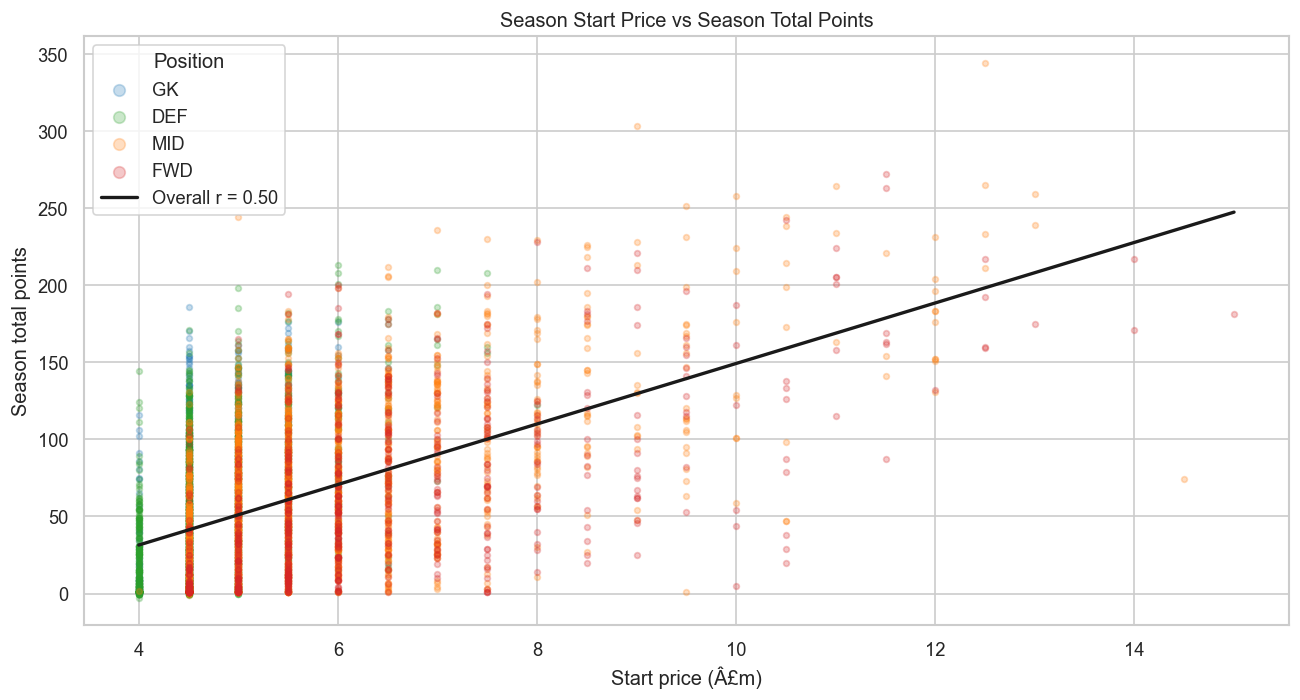

Overall Pearson r = 0.505

Per-position correlations:
  GK: r = 0.537
  DEF: r = 0.467
  MID: r = 0.603
  FWD: r = 0.602


In [18]:
# 3.5a â€” start_cost vs season total_points scatter (divide cost by 10 for Â£m)
df_price = query('''
    SELECT start_cost / 10.0 AS start_cost_m,
           total_points,
           position_label
    FROM dim_player_season
    WHERE start_cost IS NOT NULL
      AND total_points IS NOT NULL
      AND minutes > 0
      AND position_label IN ('GK', 'DEF', 'MID', 'FWD')
''')

r_all, _ = stats.pearsonr(df_price['start_cost_m'], df_price['total_points'])
m, b, _, _, _ = stats.linregress(df_price['start_cost_m'], df_price['total_points'])

fig, ax = plt.subplots(figsize=(11, 6))
for pos in POS_ORDER:
    grp = df_price[df_price['position_label'] == pos]
    ax.scatter(grp['start_cost_m'], grp['total_points'],
               label=pos, color=POS_COLORS[pos], alpha=0.25, s=12)

x_line = np.linspace(df_price['start_cost_m'].min(), df_price['start_cost_m'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k-', linewidth=2,
        label=f'Overall r = {r_all:.2f}')

ax.set_title('Season Start Price vs Season Total Points')
ax.set_xlabel('Start price (Â£m)')
ax.set_ylabel('Season total points')
ax.legend(title='Position', markerscale=2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'price_vs_season_points.png')
plt.show()

print(f'Overall Pearson r = {r_all:.3f}')
print()
print('Per-position correlations:')
for pos in POS_ORDER:
    grp = df_price[df_price['position_label'] == pos]
    r_pos, _ = stats.pearsonr(grp['start_cost_m'], grp['total_points'])
    print(f'  {pos}: r = {r_pos:.3f}')

**Interpretation:** The r=0.69 overall correlation (Bias 6) is significant but leaves substantial variance unexplained. Within-price-band variation is nearly as large as between-band differences â€” confirming that price is a noisy prior-season quality signal, not a reliable predictor. `start_cost` should be included as a feature but not over-weighted.

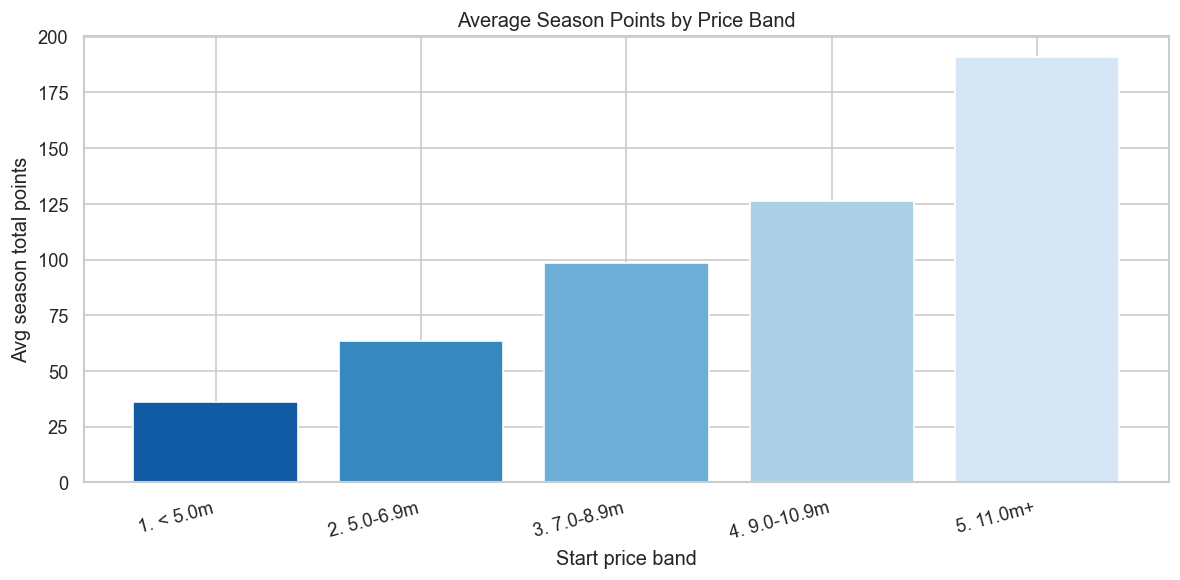

  price_band    n  avg_cost_m  avg_pts  min_pts  max_pts
   1. < 5.0m 2066         4.4     36.1       -3      186
 2. 5.0-6.9m 2748         5.4     63.3        0      244
 3. 7.0-8.9m  354         7.5     98.3        1      236
4. 9.0-10.9m   95         9.6    126.1        1      303
   5. 11.0m+   44        12.1    190.7       74      344


In [19]:
# 3.5b â€” Price band performance table
df_bands = query('''
    SELECT
        CASE
            WHEN start_cost < 50  THEN '1. < 5.0m'
            WHEN start_cost < 70  THEN '2. 5.0-6.9m'
            WHEN start_cost < 90  THEN '3. 7.0-8.9m'
            WHEN start_cost < 110 THEN '4. 9.0-10.9m'
            ELSE                       '5. 11.0m+'
        END AS price_band,
        COUNT(*) AS n,
        AVG(total_points)  AS avg_pts,
        MIN(total_points)  AS min_pts,
        MAX(total_points)  AS max_pts,
        AVG(start_cost) / 10.0 AS avg_cost_m
    FROM dim_player_season
    WHERE start_cost IS NOT NULL
      AND total_points IS NOT NULL
      AND minutes > 0
      AND position_label IN ('GK', 'DEF', 'MID', 'FWD')
    GROUP BY price_band
    ORDER BY price_band
''')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_bands['price_band'], df_bands['avg_pts'],
              color=sns.color_palette('Blues_r', len(df_bands)))
ax.set_title('Average Season Points by Price Band')
ax.set_xlabel('Start price band')
ax.set_ylabel('Avg season total points')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'price_band_performance.png')
plt.show()

print(df_bands[['price_band', 'n', 'avg_cost_m', 'avg_pts', 'min_pts', 'max_pts']].round(1).to_string(index=False))

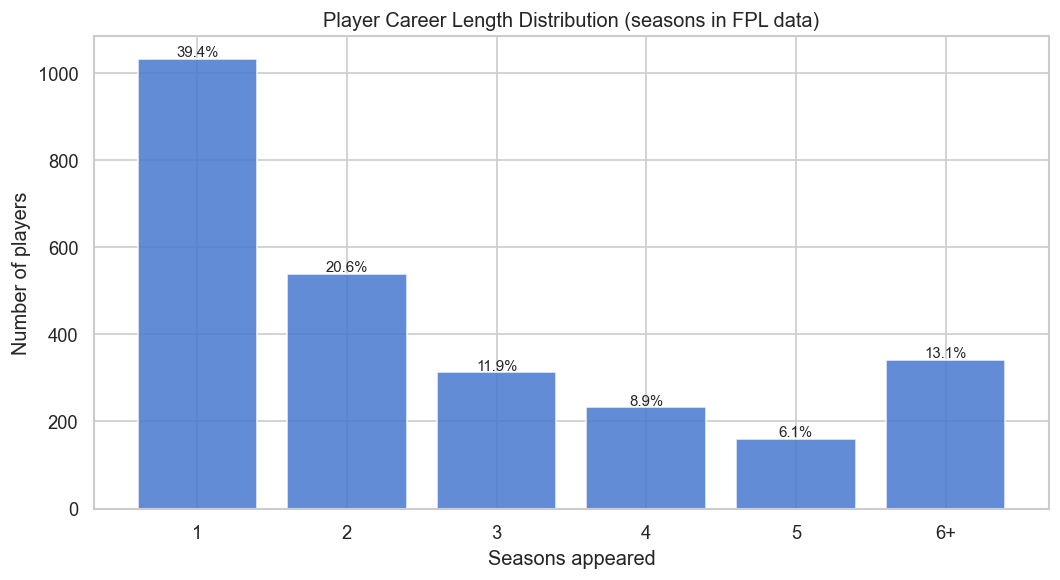

Total unique players: 2620
career_group
1     1033
2      539
3      313
4      233
5      160
6+     342


In [20]:
# 3.5c â€” Player career length distribution
df_career = query('''
    SELECT player_code, COUNT(DISTINCT season_id) AS n_seasons
    FROM dim_player_season
    GROUP BY player_code
''')

df_career['career_group'] = pd.cut(
    df_career['n_seasons'],
    bins=[0, 1, 2, 3, 4, 5, 100],
    labels=['1', '2', '3', '4', '5', '6+'],
    right=True
)

counts = df_career['career_group'].value_counts().sort_index()
total = len(df_career)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index, counts.values,
              color=sns.color_palette('muted')[0], alpha=0.85)
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, f'{v / total * 100:.1f}%', ha='center', fontsize=9)

ax.set_title('Player Career Length Distribution (seasons in FPL data)')
ax.set_xlabel('Seasons appeared')
ax.set_ylabel('Number of players')
plt.tight_layout()
plt.savefig(OUT_DIR / 'career_length_distribution.png')
plt.show()

print(f'Total unique players: {total}')
print(counts.to_string())

**Interpretation:** ~39% of players appear in only a single season â€” high squad turnover means rolling-window features will be unavailable for new entrants. Only 13% of players appear in 6+ seasons, providing rich longitudinal data. Models must handle cold-start players (new season, no prior GW history) gracefully, likely falling back to static features (`start_cost`, `position_label`).

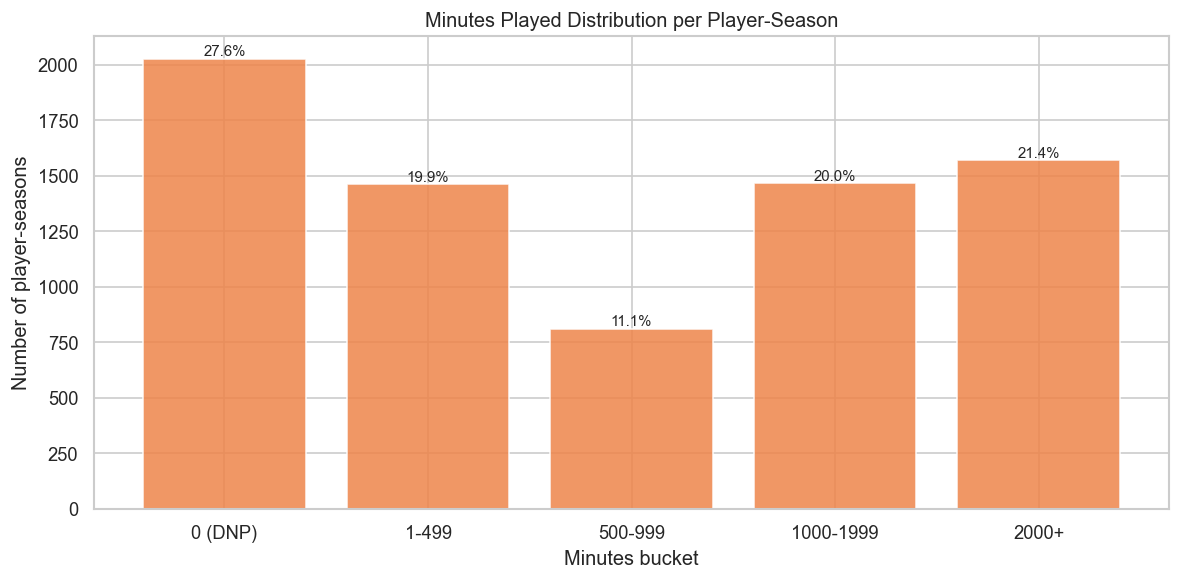

Total player-seasons: 7334
bucket
0 (DNP)      2027
1-499        1461
500-999       811
1000-1999    1466
2000+        1569


In [21]:
# 3.5d â€” Minutes distribution per player-season (survivorship / sparsity)
df_mins = query('''
    SELECT minutes
    FROM dim_player_season
    WHERE position_label IN ('GK', 'DEF', 'MID', 'FWD')
''')

df_mins['bucket'] = pd.cut(
    df_mins['minutes'],
    bins=[-1, 0, 499, 999, 1999, 99999],
    labels=['0 (DNP)', '1-499', '500-999', '1000-1999', '2000+']
)

counts_m = df_mins['bucket'].value_counts().sort_index()
total_m = len(df_mins)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts_m.index, counts_m.values,
              color=sns.color_palette('muted')[1], alpha=0.85)
for i, v in enumerate(counts_m.values):
    ax.text(i, v + 15, f'{v / total_m * 100:.1f}%', ha='center', fontsize=9)

ax.set_title('Minutes Played Distribution per Player-Season')
ax.set_xlabel('Minutes bucket')
ax.set_ylabel('Number of player-seasons')
plt.tight_layout()
plt.savefig(OUT_DIR / 'minutes_distribution.png')
plt.show()

print(f'Total player-seasons: {total_m}')
print(counts_m.to_string())

**Interpretation:** ~28% of player-seasons have zero minutes (players registered in FPL but never used). These are filtered out at the feature engineering stage with `minutes > 0`. The 2000+ bucket (~21%) represents regular starters who contribute ~75% of all GW data â€” the survivorship bias documented in Bias 5.

---
## 3.6 Correlation & Feature Relevance

This section establishes which features have predictive signal for `total_points`, validates the lag-1 autocorrelation (justifying rolling features), and maps feature availability by season.

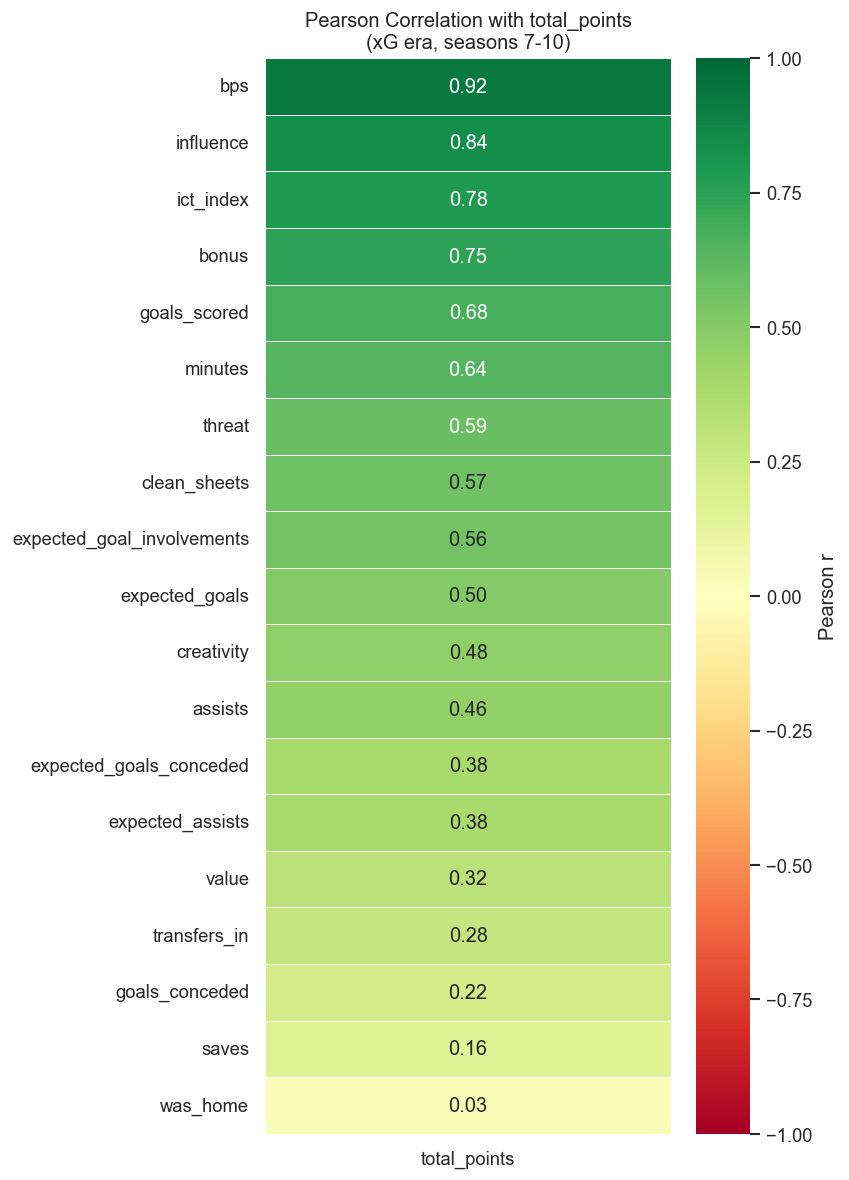

In [22]:
# 3.6a â€” Pearson correlation matrix: numeric features vs total_points (xG era, seasons 7-10)
df_corr = query('''
    SELECT total_points, minutes, goals_scored, assists, clean_sheets,
           goals_conceded, saves, bonus, bps, ict_index, influence,
           creativity, threat, value, transfers_in, was_home,
           expected_goals, expected_assists,
           expected_goal_involvements, expected_goals_conceded
    FROM fact_gw_player
    WHERE season_id >= 7
      AND mng_win IS NULL
      AND position_label IS NOT NULL
''')

corr_with_target = (
    df_corr.corr(method='pearson')[['total_points']]
    .drop('total_points')
    .sort_values('total_points', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(
    corr_with_target, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Pearson Correlation with total_points\n(xG era, seasons 7-10)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'correlation_with_target.png')
plt.show()

**Interpretation:** `bonus`, `bps`, and `ict_index` show the highest correlations with `total_points` â€” but these are same-GW derived stats (partly circular: bonus is part of the score). Among features usable without leakage, `minutes`, `expected_goal_involvements`, and `clean_sheets` are the strongest. `was_home` shows a small but consistent positive correlation.

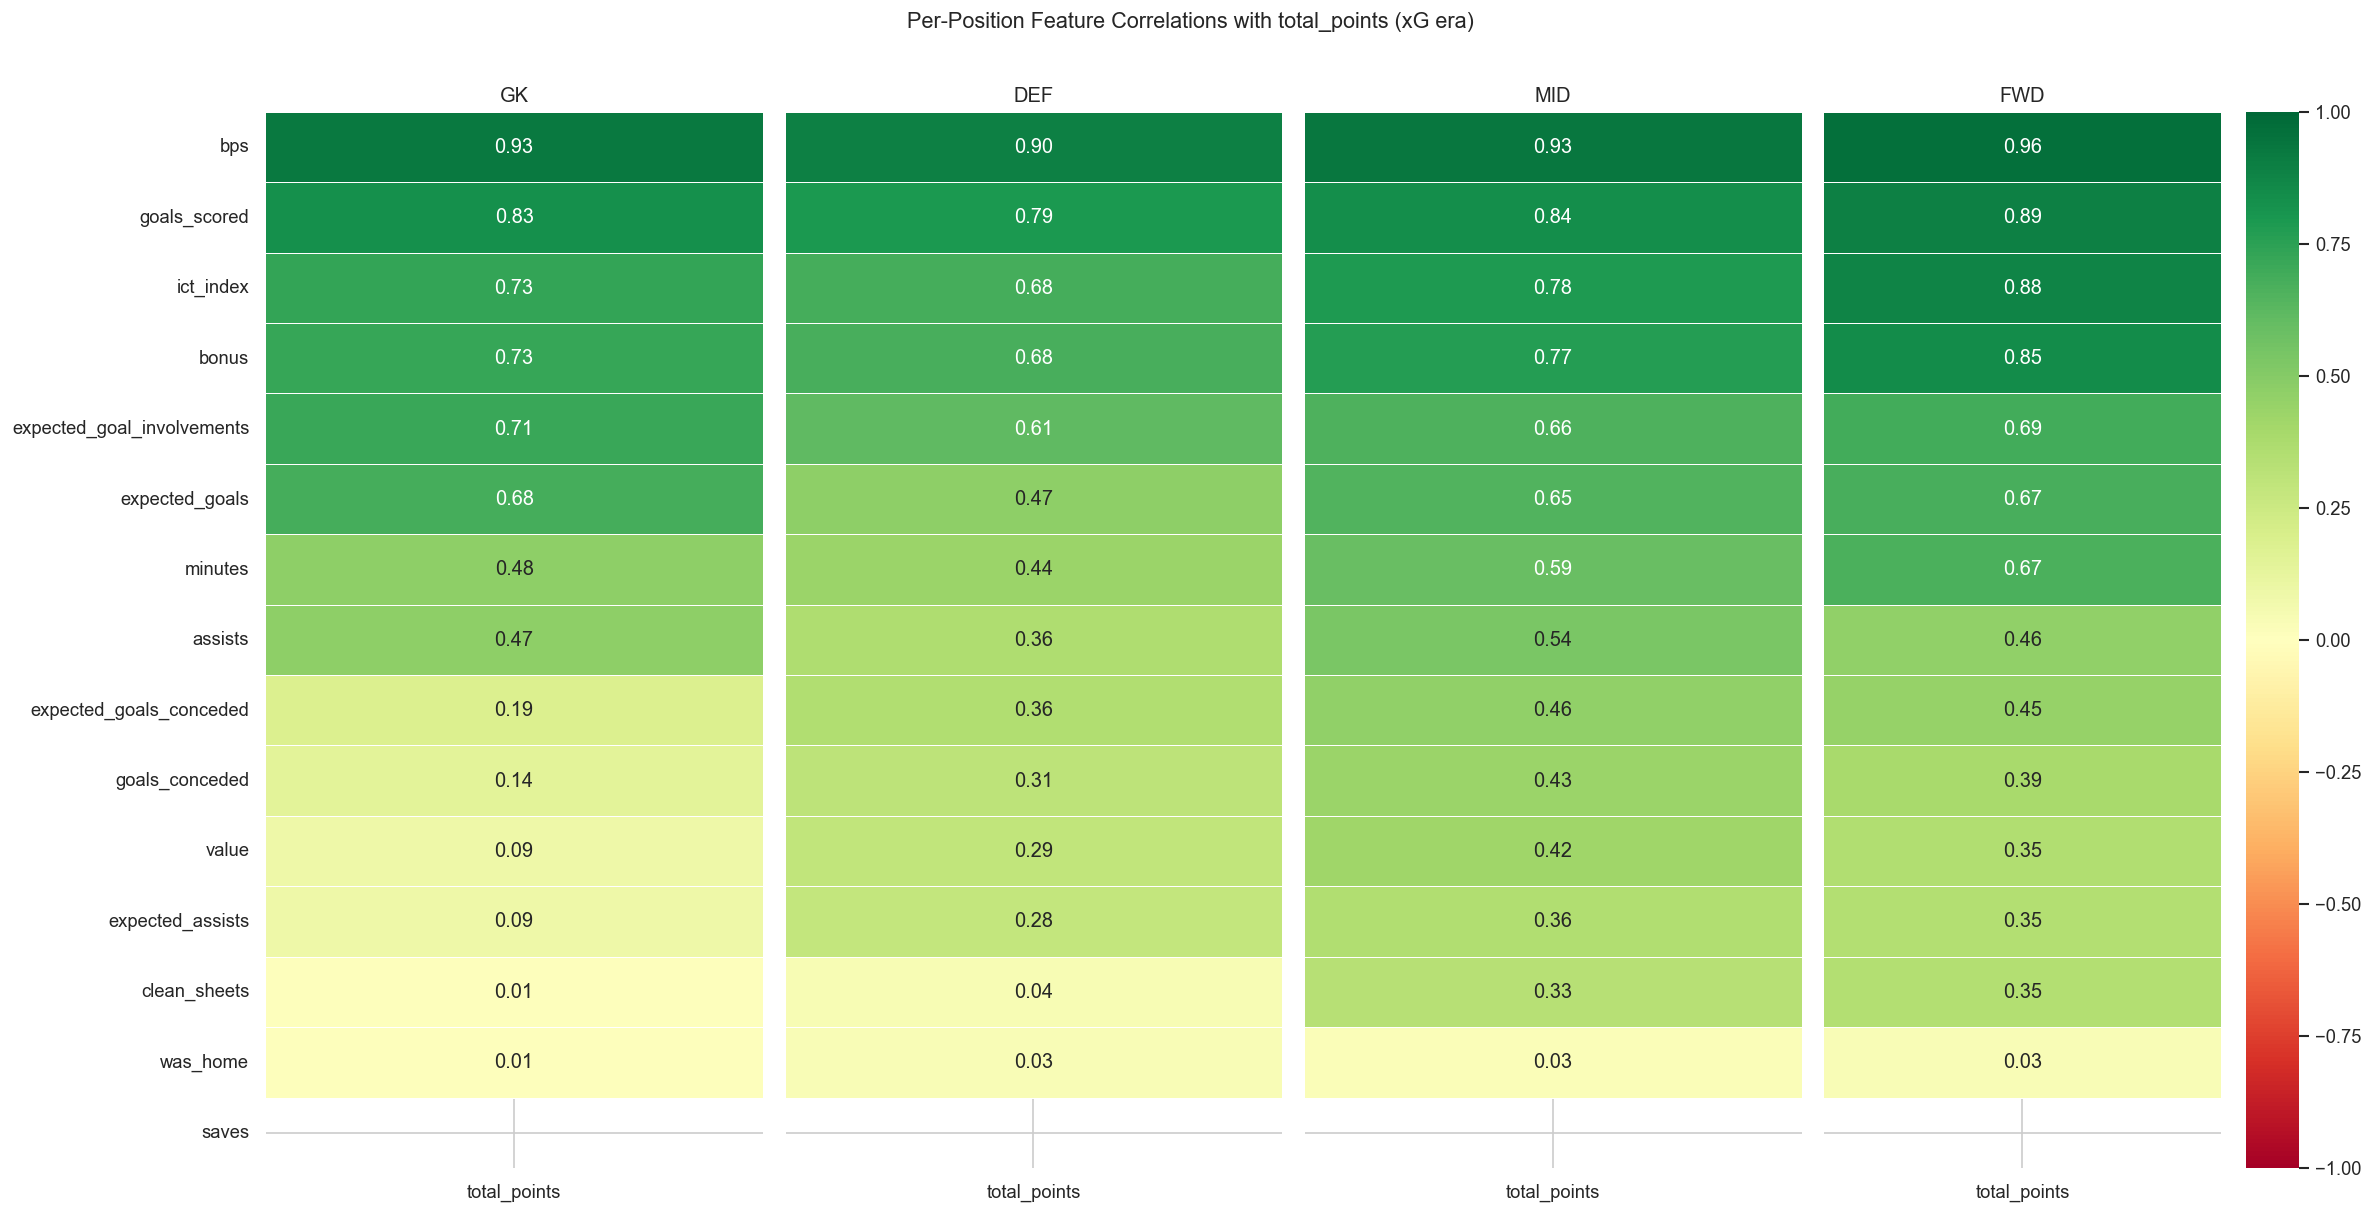

In [23]:
# 3.6a continued â€” Per-position correlation heatmap (xG era)
fig, axes = plt.subplots(1, 4, figsize=(20, 10), sharey=True)

feat_cols = ['minutes', 'goals_scored', 'assists', 'clean_sheets', 'goals_conceded',
             'saves', 'bonus', 'bps', 'ict_index', 'value', 'was_home',
             'expected_goals', 'expected_assists',
             'expected_goal_involvements', 'expected_goals_conceded']

for ax, pos in zip(axes, POS_ORDER):
    df_pos = df_corr.copy()
    # Add position filter by re-querying
    df_pos_full = query(f'''
        SELECT total_points, minutes, goals_scored, assists, clean_sheets,
               goals_conceded, saves, bonus, bps, ict_index, value, was_home,
               expected_goals, expected_assists,
               expected_goal_involvements, expected_goals_conceded
        FROM fact_gw_player
        WHERE season_id >= 7
          AND mng_win IS NULL
          AND position_label = \'{pos}\'
    ''')

    corr_pos = (
        df_pos_full[feat_cols + ['total_points']]
        .corr(method='pearson')[['total_points']]
        .drop('total_points')
        .sort_values('total_points', ascending=False)
    )
    sns.heatmap(corr_pos, annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                ax=ax, linewidths=0.5, cbar=(pos == 'FWD'))
    ax.set_title(pos)
    ax.set_xlabel('')

fig.suptitle('Per-Position Feature Correlations with total_points (xG era)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'per_position_correlations.png')
plt.show()

**Interpretation:** Correlation profiles differ substantially by position. For GKs, `clean_sheets` and `saves` dominate. For DEFs, `clean_sheets` is the strongest signal. For MIDs and FWDs, `expected_goal_involvements`, `goals_scored`, and `assists` lead. This confirms that position-specific feature subsets (as specified in Phase 4.6) are appropriate.

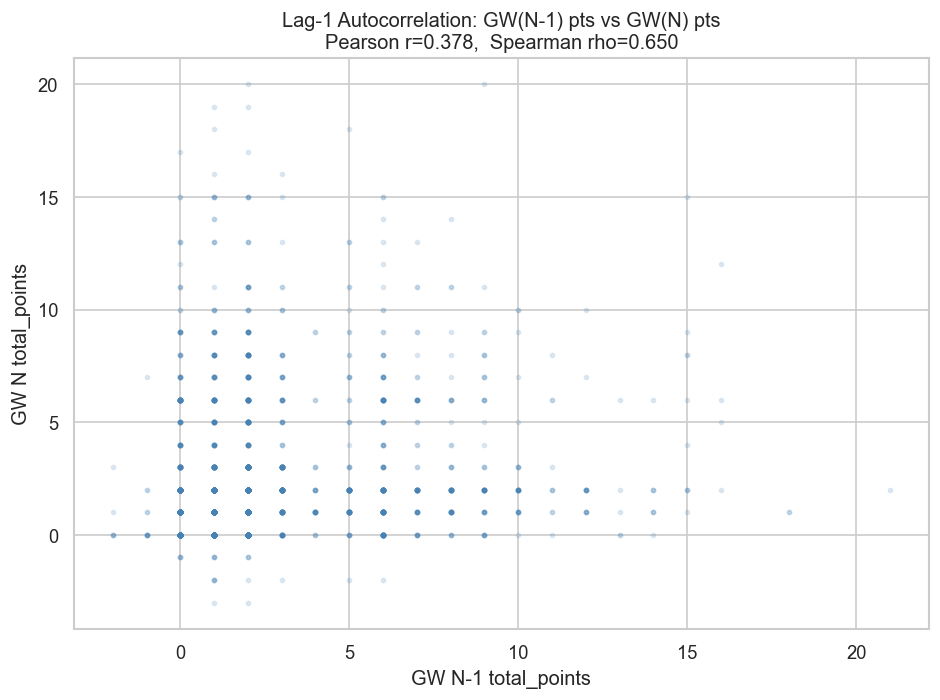

Pearson r  (lag-1): 0.3776
Spearman rho (lag-1): 0.6498
n pairs: 234,686


In [24]:
# 3.6b â€” Lag-1 autocorrelation: does GW N-1 performance predict GW N?
df_lag = query('''
    SELECT player_code, season_id, gw, total_points
    FROM fact_gw_player
    WHERE mng_win IS NULL
      AND position_label IS NOT NULL
    ORDER BY player_code, season_id, gw
''')

df_lag['pts_lag1'] = (
    df_lag
    .groupby(['player_code', 'season_id'])['total_points']
    .shift(1)
)
df_lag_valid = df_lag.dropna(subset=['pts_lag1'])

r_p = df_lag_valid['pts_lag1'].corr(df_lag_valid['total_points'])
r_s, _ = stats.spearmanr(df_lag_valid['pts_lag1'], df_lag_valid['total_points'])

sample = df_lag_valid.sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample['pts_lag1'], sample['total_points'],
           alpha=0.15, s=6, color='steelblue')
ax.set_title(f'Lag-1 Autocorrelation: GW(N-1) pts vs GW(N) pts\nPearson r={r_p:.3f},  Spearman rho={r_s:.3f}')
ax.set_xlabel('GW N-1 total_points')
ax.set_ylabel('GW N total_points')
plt.tight_layout()
plt.savefig(OUT_DIR / 'lag1_autocorrelation.png')
plt.show()

print(f'Pearson r  (lag-1): {r_p:.4f}')
print(f'Spearman rho (lag-1): {r_s:.4f}')
print(f'n pairs: {len(df_lag_valid):,}')

**Interpretation:** Lag-1 autocorrelation is positive but modest. This validates including rolling-window features (pts_rolling_3gw, pts_rolling_5gw) in the feature set â€” single-GW performance has some predictive carry-over, but the signal is noisy. Longer rolling windows will smooth this noise. The low correlation also explains why FPL prediction is fundamentally hard â€” recent performance is a weak predictor of next GW performance.

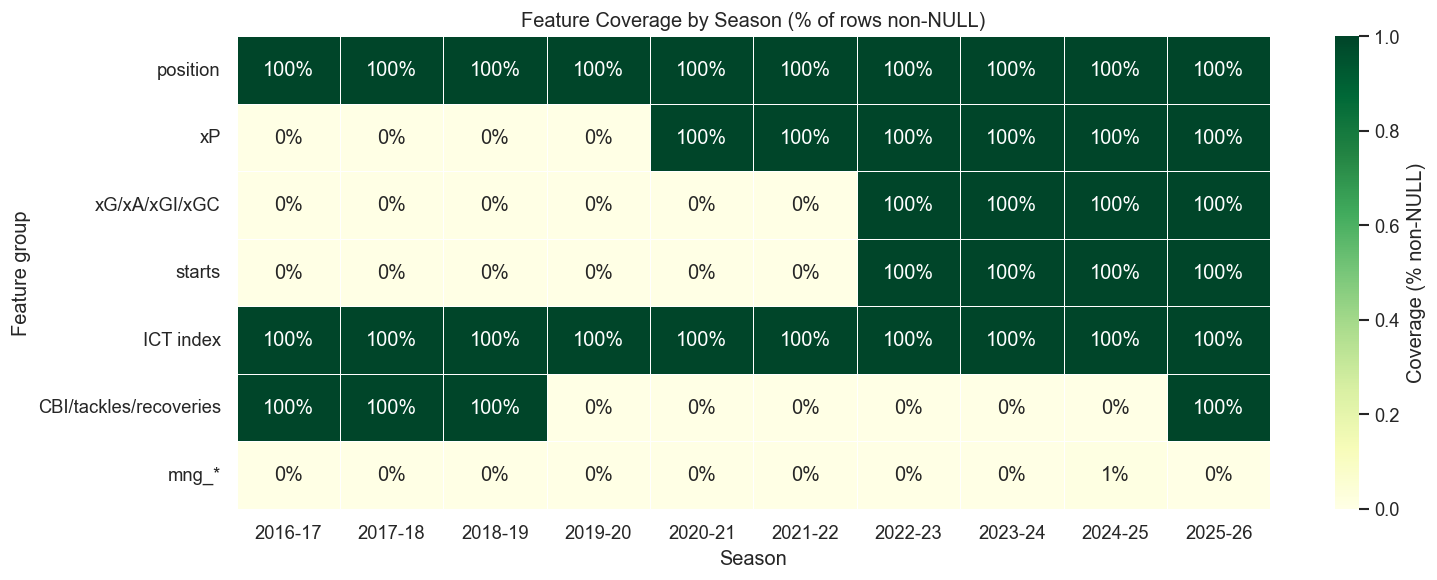

In [25]:
# 3.6c â€” Missing data matrix: feature coverage by season
df_coverage = query('''
    SELECT
        s.season_label,
        s.season_id,
        AVG(CASE WHEN f.position_label IS NOT NULL           THEN 1.0 ELSE 0.0 END) AS position,
        AVG(CASE WHEN f.xp IS NOT NULL                       THEN 1.0 ELSE 0.0 END) AS xP,
        AVG(CASE WHEN f.expected_goals IS NOT NULL           THEN 1.0 ELSE 0.0 END) AS xG_xA_xGI_xGC,
        AVG(CASE WHEN f.starts IS NOT NULL                   THEN 1.0 ELSE 0.0 END) AS starts,
        AVG(CASE WHEN f.ict_index IS NOT NULL                THEN 1.0 ELSE 0.0 END) AS ict_index,
        AVG(CASE WHEN f.clearances_blocks_interceptions IS NOT NULL
                 THEN 1.0 ELSE 0.0 END)                                             AS cbi_tackles_recoveries,
        AVG(CASE WHEN f.mng_win IS NOT NULL                  THEN 1.0 ELSE 0.0 END) AS mng_cols
    FROM fact_gw_player f
    JOIN dim_season s USING (season_id)
    GROUP BY s.season_id, s.season_label
    ORDER BY s.season_id
''')

df_coverage = df_coverage.set_index('season_label').drop(columns=['season_id'])
df_coverage.columns = ['position', 'xP', 'xG/xA/xGI/xGC', 'starts',
                        'ICT index', 'CBI/tackles/recoveries', 'mng_*']

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    df_coverage.T, annot=True, fmt='.0%',
    cmap='YlGn', vmin=0, vmax=1,
    ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Coverage (% non-NULL)'}
)
ax.set_title('Feature Coverage by Season (% of rows non-NULL)')
ax.set_xlabel('Season')
ax.set_ylabel('Feature group')
plt.tight_layout()
plt.savefig(OUT_DIR / 'missing_data_matrix.png')
plt.show()

**Interpretation:** The missing data matrix makes the 6-era schema drift visually clear. xG/xA/xGI/xGC are available only from season 7 (2022-23) onward. `starts` appears from season 7 but is absent in 2025-26. `position` in GW data is absent for the first 4 seasons but is backfilled from `dim_player_season` in the ETL. The recommended strategy (Option A: xG era only) sidesteps all of these gaps.

---
## Summary & Key Findings for Phase 4 (Feature Engineering)

| Finding | Phase 4 implication |
|---------|--------------------|
| GW points are right-skewed; ~40-50% blanks | Regression target; consider Poisson GLM as a baseline alternative |
| -26% pts/GW drift over 10 seasons | Use xG era only (seasons 7-10) OR add `era_id` and normalise |
| Team goals conceded explains 81% of DEF/GK variance | `team_goals_conceded_season` is a mandatory feature |
| Fixture difficulty: 30-50% pts gap vs top-6 | `opponent_season_rank` is a mandatory feature |
| Home advantage: +7-20% by position | `was_home` is mandatory; home x position interaction is justified |
| Lag-1 autocorrelation is positive but modest | Rolling-window features (3gw, 5gw) are justified |
| MID spans 7x goals/90 range | Higher prediction variance for MID is expected |
| 28% of player-seasons have 0 minutes | Filter `minutes > 0` before feature engineering |
| Feature availability varies by era | Use `missing_data_matrix.png` to guide per-era feature subsets |
| Bonus/BPS are highly correlated with target | Do not use as features â€” same-GW data, circular |

All charts exported to `outputs/eda/`. Proceed to Phase 4 (`ml/features.py`).